# Trabalho Final - Inteligência Computacional

Este notebook apresenta todos os experimentos de regressão e classificação multiclasse conforme solicitado.

## Estrutura
- Importação de bibliotecas
- Carregamento dos dados
    - Regressão
        - Energy Efficiency Dataset
        - California Housing
    - Classificação
        - Wine Quality Dataset
        - Iris
- Pré-processamento
    - Regressão
        - Energy Efficiency Dataset
        - California Housing
    - Classificação
        - Wine Quality Dataset
        - Iris
- Configuração dos algoritmos
    - Regressão:
        - Regressão Linear
        - Random Forest Regressor
        - MLPRegressor (Rede Neural)
        - SVR (Support Vector Regressor)
        - FuzzyRegressor (exemplo simples usando lógica fuzzy)
    - Classificação:
        - Regressão Logística (LogisticRegression)
        - Random Forest Classifier
        - MLPClassifier (Rede Neural Multicamadas)
        - SVM Classifier (Support Vector Machine)
    - Métricas de Avaliação
- Execução dos experimentos
    - Experimento 01 - Regressão
        - Setup 1 - Energy Efficiency Dataset
            - Regressão Linear
            - Random Forest Regressor
            - MLPRegressor (Rede Neural)
            - SVR (Support Vector Regressor)
            - FuzzyRegressor (exemplo simples usando lógica fuzzy)
        - Setup 2 - California Housing
            - Regressão Linear
            - Random Forest Regressor
            - MLPRegressor (Rede Neural)
            - SVR (Support Vector Regressor)
            - FuzzyRegressor (exemplo simples usando lógica fuzzy)
    - Experimento 02 - Classificação Multiclasse
        - Setup 1 - Wine Quality Dataset
            - Regressão Logística (LogisticRegression)
            - Random Forest Classifier
            - MLPClassifier (Rede Neural Multicamadas)
            - SVM Classifier (Support Vector Machine)
        - Setup 2 - Iris
            - Regressão Logística (LogisticRegression)
            - Random Forest Classifier
            - MLPClassifier (Rede Neural Multicamadas)
            - SVM Classifier (Support Vector Machine)
- Análise dos resultados
- Justificativas e análise crítica

%pip install -r requirements.txt

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score, cohen_kappa_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.svm import SVR, SVC
import warnings
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.utils import resample
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import os


warnings.filterwarnings('ignore')



# Garante que a pasta 'graficos' existe
os.makedirs('graficos', exist_ok=True)

## Carregamento dos Dados
Serão utilizados os seguintes datasets:
- Regressão: `energy_efficiency.csv`, `california_housing.csv`
- Classificação: `winequality_red.csv`, `iris.csv`
Os arquivos estão na pasta `datasets_salvos/`.

In [2]:
# Carregando os datasets
energy = pd.read_csv('datasets_salvos/energy_efficiency.csv')
california = pd.read_csv('datasets_salvos/california_housing.csv')
wine = pd.read_csv('datasets_salvos/winequality_red.csv')
iris = pd.read_csv('datasets_salvos/iris.csv')
print('Energy Efficiency Dataset:')
display(energy.head())
print('California Housing Dataset:')
display(california.head())
print('Wine Quality Red Dataset:')
display(wine.head())
print('Iris Dataset:')
display(iris.head())

Energy Efficiency Dataset:


,X1,X2,X3,X4,X5,X6,X7,X8,Y1,Y2
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


California Housing Dataset:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Wine Quality Red Dataset:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Iris Dataset:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Pré-processamento dos Dados
Serão aplicadas as etapas de tratamento de valores faltantes, normalização/padronização e codificação de variáveis categóricas.

In [3]:
# Funções de pré-processamento
def preprocess_regression(df, target_cols):
    df = df.dropna()
    X = df.drop(columns=target_cols)
    y = df[target_cols]
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled, y

def preprocess_classification(df, target_col, balance=False):
    print(f'Tamanho do DataFrame antes do dropna: {df.shape}')
    df = df.dropna()
    print(f'Tamanho do DataFrame após o dropna e antes do balanceamento: {df.shape}')
    X = df.drop(columns=[target_col])
    y = df[target_col]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)

    if balance:
        # Concatena X e y para facilitar o balanceamento
        data = np.hstack((X_scaled, y.values.reshape(-1, 1)))
        classes = np.unique(y)
        max_count = max([np.sum(y == c) for c in classes])
        balanced = []
        for c in classes:
            class_data = data[y == c]
            class_upsampled = resample(class_data, replace=True, n_samples=max_count, random_state=42)
            balanced.append(class_upsampled)
        data_balanced = np.vstack(balanced)
        np.random.shuffle(data_balanced)
        X_scaled = data_balanced[:, :-1]
        y = data_balanced[:, -1]
        print(f'Tamanho do DataFrame após o balanceamento : {X_scaled.shape}')
    return X_scaled, y
# Pré-processamento
X_energy, y_energy = preprocess_regression(energy, ['Y1', 'Y2'])
X_california, y_california = preprocess_regression(california, ['MedHouseVal'])
X_wine, y_wine = preprocess_classification(wine, 'quality', balance= False)  
X_iris, y_iris = preprocess_classification(iris, 'target', balance=False) 
X_wine_b, y_wine_b = preprocess_classification(wine, 'quality', balance=True)  
X_iris_b, y_iris_b = preprocess_classification(iris, 'target', balance=True)   

Tamanho do DataFrame antes do dropna: (1599, 12)
Tamanho do DataFrame após o dropna e antes do balanceamento: (1599, 12)
Tamanho do DataFrame antes do dropna: (150, 5)
Tamanho do DataFrame após o dropna e antes do balanceamento: (150, 5)
Tamanho do DataFrame antes do dropna: (1599, 12)
Tamanho do DataFrame após o dropna e antes do balanceamento: (1599, 12)
Tamanho do DataFrame após o balanceamento : (4086, 11)
Tamanho do DataFrame antes do dropna: (150, 5)
Tamanho do DataFrame após o dropna e antes do balanceamento: (150, 5)
Tamanho do DataFrame após o balanceamento : (150, 4)


## Configuração dos Algoritmos

### Métricas

In [4]:
def plot_confusion_matrix(model, X_test, y_test, title='Matriz de Confusão', filename=None):
    plt.figure(figsize=(6,6))
    # Gera a matriz de confusão já normalizada em porcentagem
    disp = ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, cmap=plt.cm.Blues, normalize='true'
    )
    plt.title(f"{title}")
    # Remove os valores absolutos (deixa só a porcentagem)
    # O próprio ConfusionMatrixDisplay já imprime os valores normalizados
    # Ajusta os valores para mostrar como porcentagem (em vez de fração)
    cm = disp.confusion_matrix
    n_classes = cm.shape[0]
    # Atualiza os textos para mostrar porcentagem
    for text in disp.text_.ravel():
        val = float(text.get_text())
        text.set_text(f"{val*100:.1f}%")
    plt.savefig(f'graficos/{filename}.png', bbox_inches='tight')
    plt.show()

def plot_regression_scatter(y_true, y_pred, title='Dispersão - Regressão', filename=None):
    plt.figure(figsize=(6,6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.xlabel('Valor Real')
    plt.ylabel('Valor Previsto')
    plt.title(title)
    plt.grid(True)
    plt.savefig(f'graficos/{filename}.png', bbox_inches='tight')
    plt.show()

In [5]:
def regression_metrics(y_true, y_pred):
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
    rmse = mean_squared_error(y_true, y_pred) ** 0.5  # Calcula RMSE manualmente
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2}

def classification_metrics(y_true, y_pred):
    from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score
    return {
        'Acuracia': accuracy_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred, average='weighted'),
        'Kappa': cohen_kappa_score(y_true, y_pred)
    }

### Treinamento Regressão

In [6]:
def train_linear_regression(X, y):
    """
    Treina um modelo LinearRegression do scikit-learn.
    """
    # Para regressão linear, geralmente não há muitos hiperparâmetros para tunar.
    # O padrão já é o ideal para a maioria dos casos.
    model = LinearRegression(
        fit_intercept=True,
        copy_X=True,
        n_jobs=-1,      # Usa todos os núcleos disponíveis
        positive=False
    )
    model.fit(X, y)
    return model

def train_random_forest_regressor(X, y):
    """
    Treina um modelo RandomForestRegressor do scikit-learn com hiperparâmetros otimizados.
    """
    model = RandomForestRegressor(
        n_estimators=300,             # Mais árvores para maior robustez
        criterion='squared_error',
        max_depth=20,                 # Limita profundidade para evitar overfitting
        min_samples_split=4,          # Mais amostras para split, reduz overfitting
        min_samples_leaf=2,           # Mais amostras por folha, reduz overfitting
        min_weight_fraction_leaf=0.0,
        max_features='sqrt',          # sqrt é padrão e geralmente melhora generalização
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=True,               # Usa out-of-bag para validação interna
        n_jobs=-1,                    # Usa todos os núcleos disponíveis
        random_state=42,
        verbose=0,
        warm_start=False,
        ccp_alpha=0.0,
        max_samples=None
    )
    model.fit(X, y)
    return model

def train_mlp_regressor(X, y):
    """
    Treina um modelo MLPRegressor do scikit-learn com hiperparâmetros otimizados.
    """
    model = MLPRegressor(
        hidden_layer_sizes=(128, 64, 32),  # Mais camadas e neurônios
        activation='relu',
        solver='adam',
        alpha=0.001,                       # Regularização L2 um pouco maior
        batch_size=32,                     # Mini-batch para melhor convergência
        learning_rate='adaptive',          # Taxa de aprendizado adaptativa
        learning_rate_init=0.005,          # Taxa de aprendizado inicial maior
        max_iter=1000,                     # Mais iterações
        shuffle=True,
        random_state=42,
        tol=1e-4,
        verbose=False,
        early_stopping=True,               # Para evitar overfitting
        validation_fraction=0.15,          # Mais dados para validação
        n_iter_no_change=20,               # Mais paciência para early stopping
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8,
        power_t=0.5,
        warm_start=False,
        momentum=0.9,
        nesterovs_momentum=True,
        max_fun=20000
    )
    model.fit(X, y)
    return model

def train_svr(X, y):
    """
    Treina um modelo SVR (Support Vector Regressor) do scikit-learn com hiperparâmetros otimizados.
    """
    model = SVR(
        kernel='rbf',
        degree=3,
        gamma='auto',         # 'auto' pode funcionar melhor para dados normalizados
        coef0=0.0,
        tol=1e-4,             # Tolerância menor para melhor ajuste
        C=10.0,               # Penalização maior para menor viés
        epsilon=0.05,         # Margem menor para maior precisão
        shrinking=True,
        cache_size=500,       # Mais memória para acelerar
        verbose=False,
        max_iter=2000         # Limita número de iterações
    )
    model.fit(X, y)
    return model

### Treinamento de Classificação

In [7]:
def train_logistic_regression(X, y):
    """
    Treina um modelo LogisticRegression do scikit-learn com hiperparâmetros otimizados.
    """
    model = LogisticRegression(
        penalty='l2',
        dual=False,
        tol=1e-5,                  # Tolerância menor para maior precisão
        C=2.0,                     # Menor regularização (maior C)
        fit_intercept=True,
        intercept_scaling=1,
        class_weight='balanced',   # Compensa desbalanceamento de classes
        random_state=42,
        solver='lbfgs',
        max_iter=1000,             # Mais iterações para convergência
        multi_class='multinomial', # Melhor para multiclasse
        verbose=0,
        warm_start=False,
        n_jobs=-1,                 # Usa todos os núcleos disponíveis
        l1_ratio=None
    )
    model.fit(X, y)
    return model

def train_random_forest_classifier(X, y):
    """
    Treina um modelo RandomForestClassifier do scikit-learn com hiperparâmetros otimizados.
    """
    model = RandomForestClassifier(
        n_estimators=300,              # Mais árvores para maior robustez
        criterion='entropy',           # Entropia pode melhorar multiclasse
        max_depth=20,                  # Limita profundidade para evitar overfitting
        min_samples_split=4,           # Mais amostras para split
        min_samples_leaf=2,            # Mais amostras por folha
        min_weight_fraction_leaf=0.0,
        max_features='sqrt',
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=True,                # Out-of-bag para validação interna
        n_jobs=-1,                     # Usa todos os núcleos disponíveis
        random_state=42,
        verbose=0,
        warm_start=False,
        class_weight='balanced',       # Compensa desbalanceamento de classes
        ccp_alpha=0.0,
        max_samples=None
    )
    model.fit(X, y)
    return model

def train_mlp_classifier(X, y):
    """
    Treina um modelo MLPClassifier do scikit-learn com hiperparâmetros otimizados.
    """
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),  # Mais camadas e neurônios
        activation='relu',
        solver='adam',
        alpha=0.001,                       # Regularização L2 maior
        batch_size=32,                     # Mini-batch
        learning_rate='adaptive',          # Taxa de aprendizado adaptativa
        learning_rate_init=0.005,          # Taxa inicial maior
        power_t=0.5,
        max_iter=1000,                     # Mais iterações
        shuffle=True,
        random_state=42,
        tol=1e-4,
        verbose=False,
        warm_start=False,
        momentum=0.9,
        nesterovs_momentum=True,
        early_stopping=True,               # Early stopping para evitar overfitting
        validation_fraction=0.15,          # Mais dados para validação
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8,
        n_iter_no_change=20,               # Mais paciência para early stopping
        max_fun=20000
    )
    model.fit(X, y)
    return model

def train_svm_classifier(X, y):
    """
    Treina um modelo SVC (Support Vector Classifier) do scikit-learn com hiperparâmetros otimizados.
    """
    model = SVC(
        C=10.0,                    # Penalização maior para menor viés
        kernel='rbf',
        degree=3,
        gamma='auto',              # 'auto' pode funcionar melhor para dados normalizados
        coef0=0.0,
        shrinking=True,
        probability=True,
        tol=1e-4,                  # Tolerância menor para melhor ajuste
        cache_size=500,            # Mais memória para acelerar
        class_weight='balanced',   # Compensa desbalanceamento de classes
        verbose=False,
        max_iter=2000,             # Limita número de iterações
        decision_function_shape='ovr',
        break_ties=True,           # Melhor desempate em multiclasse
        random_state=42
    )
    model.fit(X, y)
    return model

## Execução dos Experimentos
Serão realizados experimentos de regressão e classificação com 30 repetições para cada modelo e base. Com 70 para treinamento e 30 de texte. 

### Regressão

In [8]:
def run_regression_experiment(X, y, train_fn, seeds=range(1, 31), test_size=0.3, plot=False, experimento=''):
    results = []
    y_true_all = []
    y_pred_all = []
    last_model = None
    for seed in seeds:
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
        model = train_fn(X_train, y_train)
        y_pred = model.predict(X_test)
        metrics = regression_metrics(y_test, y_pred)
        results.append(metrics)
        # Guarda os valores da última repetição para o gráfico
        if seed == seeds[-1]:
            y_true_all = y_test
            y_pred_all = y_pred
            last_model = model
    df_results = pd.DataFrame(results)
    # Mostra médias e desvios padrão
    print("Médias das métricas:\n", df_results.mean())
    print("\nDesvio padrão das métricas:\n", df_results.std())
    # Plota apenas uma vez, se solicitado
    if plot:
        model_name = type(last_model).__name__ if last_model is not None else "Modelo"
        plot_regression_scatter(
            y_true_all, y_pred_all,
            title=f'Dispersão - {model_name}',
            filename=f'exp_{experimento}_{model_name}'
        )
    return df_results


### Classificação 

In [9]:
def train_logistic_regression(X, y):
    """
    Treina um modelo LogisticRegression do scikit-learn com hiperparâmetros otimizados.
    """
    model = LogisticRegression(
        penalty='l2',
        dual=False,
        tol=1e-5,                  # Tolerância menor para maior precisão
        C=2.0,                     # Menor regularização (maior C)
        fit_intercept=True,
        intercept_scaling=1,
        class_weight='balanced',   # Compensa desbalanceamento de classes
        random_state=42,
        solver='lbfgs',
        max_iter=1000,             # Mais iterações para convergência
        multi_class='multinomial', # Melhor para multiclasse
        verbose=0,
        warm_start=False,
        n_jobs=-1,                 # Usa todos os núcleos disponíveis
        l1_ratio=None
    )
    model.fit(X, y)
    return model

def train_random_forest_classifier(X, y):
    """
    Treina um modelo RandomForestClassifier do scikit-learn com hiperparâmetros otimizados.
    """
    model = RandomForestClassifier(
        n_estimators=300,              # Mais árvores para maior robustez
        criterion='entropy',           # Entropia pode melhorar multiclasse
        max_depth=20,                  # Limita profundidade para evitar overfitting
        min_samples_split=4,           # Mais amostras para split
        min_samples_leaf=2,            # Mais amostras por folha
        min_weight_fraction_leaf=0.0,
        max_features='sqrt',
        max_leaf_nodes=None,
        min_impurity_decrease=0.0,
        bootstrap=True,
        oob_score=True,                # Out-of-bag para validação interna
        n_jobs=-1,                     # Usa todos os núcleos disponíveis
        random_state=42,
        verbose=0,
        warm_start=False,
        class_weight='balanced',       # Compensa desbalanceamento de classes
        ccp_alpha=0.0,
        max_samples=None
    )
    model.fit(X, y)
    return model

def train_mlp_classifier(X, y):
    """
    Treina um modelo MLPClassifier do scikit-learn com hiperparâmetros otimizados.
    """
    model = MLPClassifier(
        hidden_layer_sizes=(128, 64, 32),  # Mais camadas e neurônios
        activation='relu',
        solver='adam',
        alpha=0.001,                       # Regularização L2 maior
        batch_size=32,                     # Mini-batch
        learning_rate='adaptive',          # Taxa de aprendizado adaptativa
        learning_rate_init=0.005,          # Taxa inicial maior
        power_t=0.5,
        max_iter=1000,                     # Mais iterações
        shuffle=True,
        random_state=42,
        tol=1e-4,
        verbose=False,
        warm_start=False,
        momentum=0.9,
        nesterovs_momentum=True,
        early_stopping=True,               # Early stopping para evitar overfitting
        validation_fraction=0.15,          # Mais dados para validação
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-8,
        n_iter_no_change=20,               # Mais paciência para early stopping
        max_fun=20000
    )
    model.fit(X, y)
    return model

def train_svm_classifier(X, y):
    """
    Treina um modelo SVC (Support Vector Classifier) do scikit-learn com hiperparâmetros otimizados.
    """
    model = SVC(
        C=10.0,                    # Penalização maior para menor viés
        kernel='rbf',
        degree=3,
        gamma='auto',              # 'auto' pode funcionar melhor para dados normalizados
        coef0=0.0,
        shrinking=True,
        probability=True,
        tol=1e-4,                  # Tolerância menor para melhor ajuste
        cache_size=500,            # Mais memória para acelerar
        class_weight='balanced',   # Compensa desbalanceamento de classes
        verbose=False,
        max_iter=2000,             # Limita número de iterações
        decision_function_shape='ovr',
        break_ties=True,           # Melhor desempate em multiclasse
        random_state=42
    )
    model.fit(X, y)
    return model

## Experimento 01 - Regressão

In [10]:
regression_results = {}
pl = True

### Setup 1 - Energy Efficiency Dataset
#### Energy Efficiency Y1

In [11]:
ex = 'energy_efficiency_y1'

##### Regressão Linear

Médias das métricas:
 RMSE    2.970777
MAE     2.109132
R2      0.912785
dtype: float64

Desvio padrão das métricas:
 RMSE    0.125832
MAE     0.102541
R2      0.007878
dtype: float64


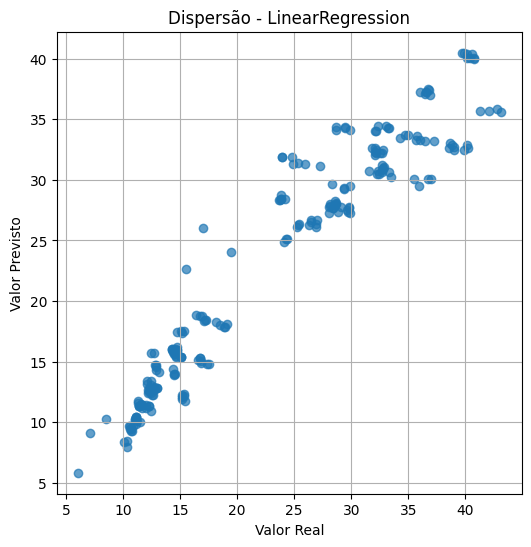


Modelo: LinearRegression (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    2.970777   2.109132   0.912785
std     0.125832   0.102541   0.007878
min     2.766455   1.918429   0.893855
25%     2.857538   2.039246   0.909378
50%     2.973330   2.104002   0.913402
75%     3.064747   2.171273   0.916508
max     3.289209   2.335462   0.925401


In [12]:
res_lr = run_regression_experiment(X_energy, y_energy['Y1'], lambda X, y: LinearRegression().fit(X, y), plot=pl, experimento=ex)
regression_results['Energy_LinearRegression_Y1'] = res_lr
print('\nModelo: LinearRegression (Energy Y1)')
print(res_lr.describe())


##### Random Forest Regressor

Médias das métricas:
 RMSE    0.885999
MAE     0.624344
R2      0.992078
dtype: float64

Desvio padrão das métricas:
 RMSE    0.130415
MAE     0.049878
R2      0.002521
dtype: float64


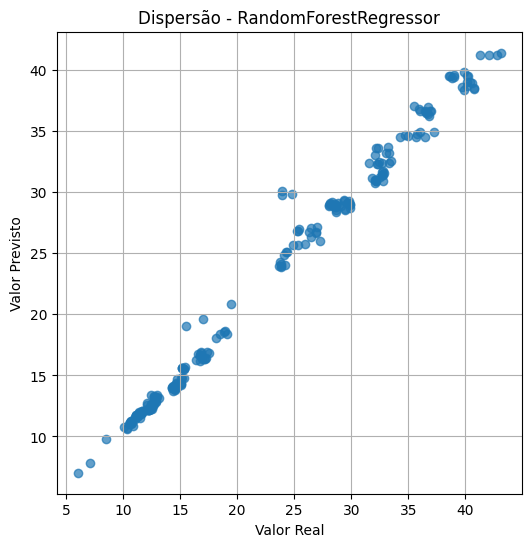


Modelo: RandomForest (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.885999   0.624344   0.992078
std     0.130415   0.049878   0.002521
min     0.705947   0.536351   0.985498
25%     0.790473   0.583276   0.991098
50%     0.842773   0.618623   0.992937
75%     0.950789   0.649961   0.993849
max     1.228539   0.744213   0.995014


In [13]:
res_rf = run_regression_experiment(X_energy, y_energy['Y1'], train_random_forest_regressor, plot=pl, experimento=ex)
regression_results['Energy_RandomForest_Y1'] = res_rf
print('\nModelo: RandomForest (Energy Y1)')
print(res_rf.describe())

##### MLPRegressor (Rede Neural Multicamadas)

Médias das métricas:
 RMSE    0.571199
MAE     0.419975
R2      0.996766
dtype: float64

Desvio padrão das métricas:
 RMSE    0.042434
MAE     0.034099
R2      0.000468
dtype: float64


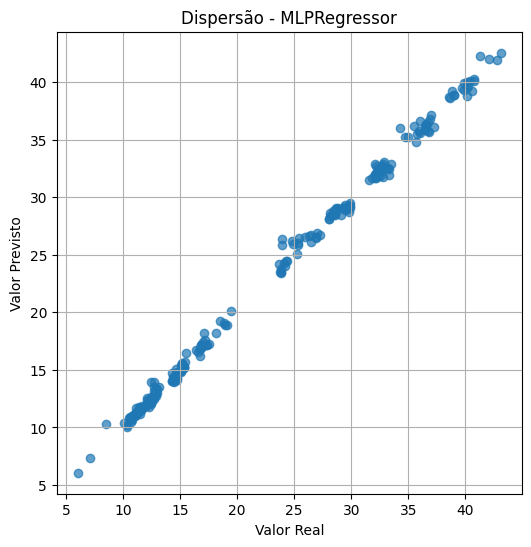


Modelo: MLPRegressor (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.571199   0.419975   0.996766
std     0.042434   0.034099   0.000468
min     0.480478   0.349994   0.995411
25%     0.546551   0.402541   0.996473
50%     0.569592   0.413877   0.996750
75%     0.598117   0.445263   0.996992
max     0.690162   0.483725   0.997879


In [ ]:
res_mlp = run_regression_experiment(X_energy, y_energy['Y1'], train_mlp_regressor, plot=pl, experimento=ex)
regression_results['Energy_MLP_Y1'] = res_mlp
print('\nModelo: MLPRegressor (Energy Y1)')
print(res_mlp.describe())

##### SVR (Support Vector Regressor)

Médias das métricas:
 RMSE    2.463135
MAE     1.372868
R2      0.939819
dtype: float64

Desvio padrão das métricas:
 RMSE    0.171928
MAE     0.101253
R2      0.008647
dtype: float64


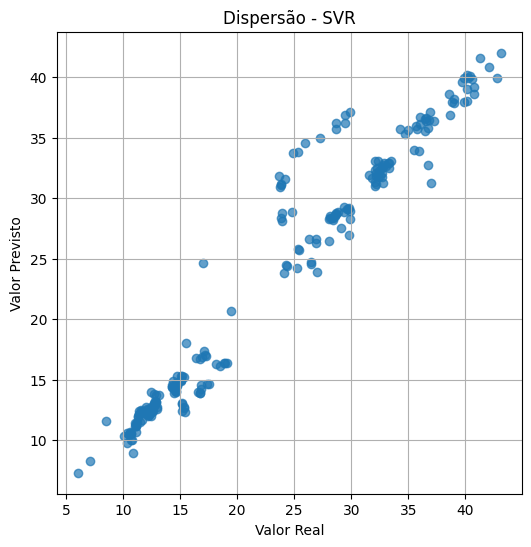


Modelo: SVR (Energy Y1)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    2.463135   1.372868   0.939819
std     0.171928   0.101253   0.008647
min     1.981091   1.150379   0.925360
25%     2.364520   1.306422   0.933425
50%     2.474695   1.364008   0.940260
75%     2.593026   1.448036   0.945094
max     2.750736   1.559491   0.962794


In [15]:
res_svr = run_regression_experiment(X_energy, y_energy['Y1'], train_svr, plot=pl, experimento=ex)
regression_results['Energy_SVR_Y1'] = res_svr
print('\nModelo: SVR (Energy Y1)')
print(res_svr.describe())


#### Energy Efficiency Y2

##### Regressão Linear

In [16]:
ex = 'energy_efficiency_y2'

Médias das métricas:
 RMSE    3.205850
MAE     2.271299
R2      0.884940
dtype: float64

Desvio padrão das métricas:
 RMSE    0.209776
MAE     0.132068
R2      0.011241
dtype: float64


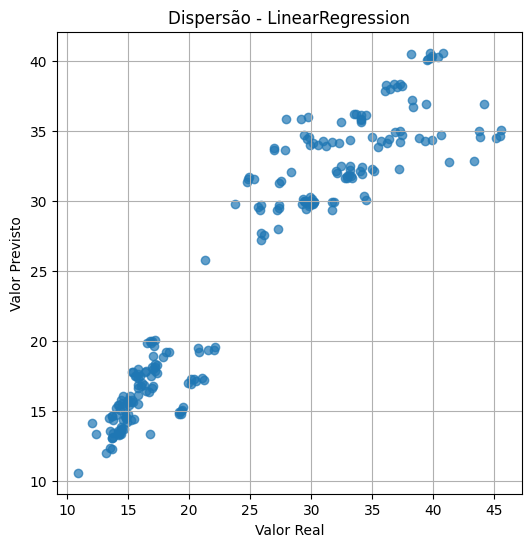


Modelo: LinearRegression (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    3.205850   2.271299   0.884940
std     0.209776   0.132068   0.011241
min     2.840911   2.035552   0.864124
25%     3.034906   2.205099   0.875335
50%     3.173195   2.255143   0.887511
75%     3.361542   2.373863   0.892975
max     3.660411   2.543625   0.903092


In [17]:
# Executa o experimento usando regressão linear e exibe estatísticas descritivas dos resultados.
res_lr2 = run_regression_experiment(X_energy, y_energy['Y2'], lambda X, y: LinearRegression().fit(X, y), plot=pl, experimento=ex)
regression_results['Energy_LinearRegression_Y2'] = res_lr2
print('\nModelo: LinearRegression (Energy Y2)')
print(res_lr2.describe())

##### Random Forest Regressor

Médias das métricas:
 RMSE    1.768182
MAE     1.193842
R2      0.964944
dtype: float64

Desvio padrão das métricas:
 RMSE    0.093535
MAE     0.062694
R2      0.003589
dtype: float64


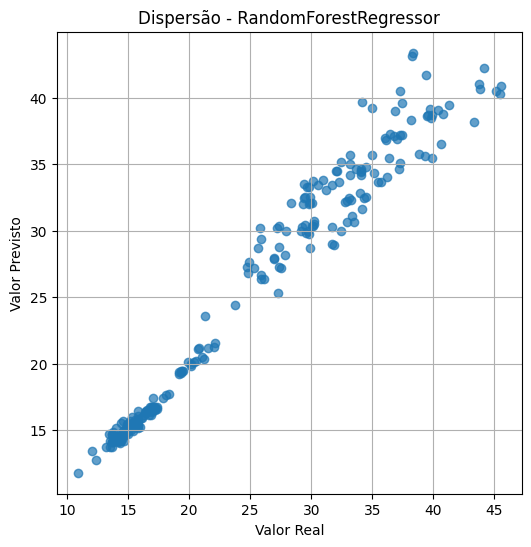


Modelo: RandomForest (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    1.768182   1.193842   0.964944
std     0.093535   0.062694   0.003589
min     1.608857   1.062446   0.952656
25%     1.725887   1.155984   0.964087
50%     1.758989   1.191479   0.965488
75%     1.815550   1.230505   0.967352
max     1.986422   1.326756   0.969897


In [18]:
# Executa o experimento usando Random Forest e exibe estatísticas descritivas dos resultados.
res_rf2 = run_regression_experiment(X_energy, y_energy['Y2'], train_random_forest_regressor, plot=pl, experimento=ex)
regression_results['Energy_RandomForest_Y2'] = res_rf2
print('\nModelo: RandomForest (Energy Y2)')
print(res_rf2.describe())

##### MLPRegressor (Rede Neural Multicamadas)

Médias das métricas:
 RMSE    1.168246
MAE     0.827578
R2      0.984498
dtype: float64

Desvio padrão das métricas:
 RMSE    0.132194
MAE     0.097946
R2      0.003668
dtype: float64


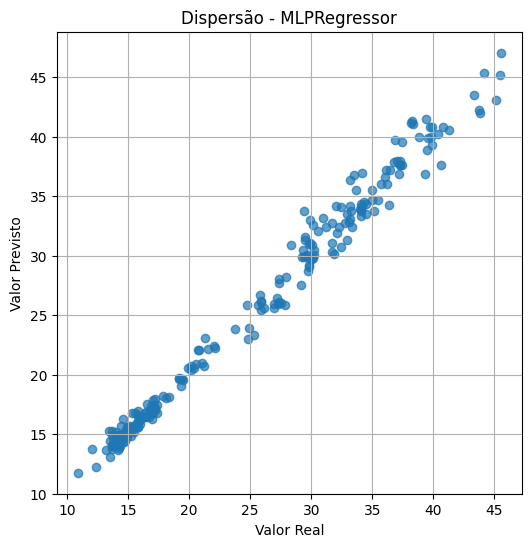


Modelo: MLPRegressor (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    1.168246   0.827578   0.984498
std     0.132194   0.097946   0.003668
min     0.912155   0.662840   0.978079
25%     1.098475   0.769754   0.981741
50%     1.124136   0.813079   0.985909
75%     1.263378   0.898874   0.987323
max     1.414003   1.006897   0.990532


In [19]:
# Executa o experimento usando rede neural MLP e exibe estatísticas descritivas dos resultados.
res_mlp2 = run_regression_experiment(X_energy, y_energy['Y2'], train_mlp_regressor, plot=pl, experimento=ex)
regression_results['Energy_MLP_Y2'] = res_mlp2
print('\nModelo: MLPRegressor (Energy Y2)')
print(res_mlp2.describe())

##### SVR (Support Vector Regressor)

Médias das métricas:
 RMSE    2.731303
MAE     1.723602
R2      0.916391
dtype: float64

Desvio padrão das métricas:
 RMSE    0.179315
MAE     0.131899
R2      0.009122
dtype: float64


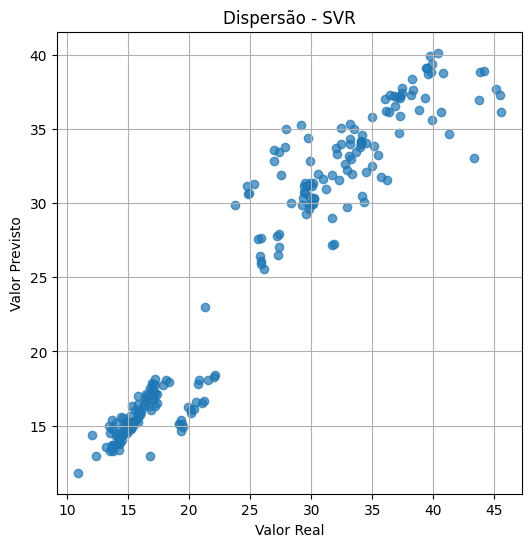


Modelo: SVR (Energy Y2)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    2.731303   1.723602   0.916391
std     0.179315   0.131899   0.009122
min     2.447136   1.503919   0.894585
25%     2.597272   1.628859   0.908595
50%     2.724643   1.713695   0.918566
75%     2.854196   1.802706   0.923388
max     3.104338   2.000109   0.934642


In [20]:
res_svr2 = run_regression_experiment(X_energy, y_energy['Y2'], train_svr, plot=pl, experimento=ex)
regression_results['Energy_SVR_Y2'] = res_svr2
print('\nModelo: SVR (Energy Y2)')
print(res_svr2.describe())

### Setup 2 - California Housing
#### California Housing

In [21]:
ex = 'california_housing'

##### Regressão Linear

Médias das métricas:
 RMSE    0.736095
MAE     0.532678
R2      0.591793
dtype: float64

Desvio padrão das métricas:
 RMSE    0.044257
MAE     0.005661
R2      0.054170
dtype: float64


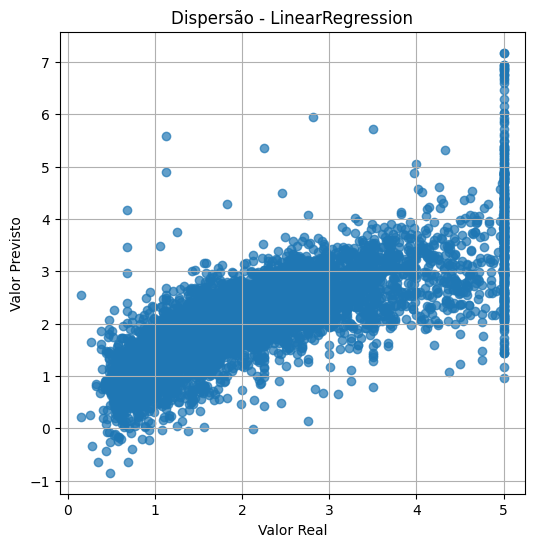


Modelo: LinearRegression (California Housing)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.736095   0.532678   0.591793
std     0.044257   0.005661   0.054170
min     0.699475   0.521820   0.309561
25%     0.722349   0.529449   0.592635
50%     0.728179   0.532285   0.602260
75%     0.733898   0.535161   0.607176
max     0.964204   0.546579   0.626203


In [22]:
res_lr_c = run_regression_experiment(X_california, y_california, lambda X, y: LinearRegression().fit(X, y), plot=pl, experimento=ex)
regression_results['California_LinearRegression'] = res_lr_c
print('\nModelo: LinearRegression (California Housing)')
print(res_lr_c.describe())


##### Random Forest Regressor

Médias das métricas:
 RMSE    0.496433
MAE     0.334188
R2      0.814883
dtype: float64

Desvio padrão das métricas:
 RMSE    0.009408
MAE     0.004724
R2      0.006042
dtype: float64


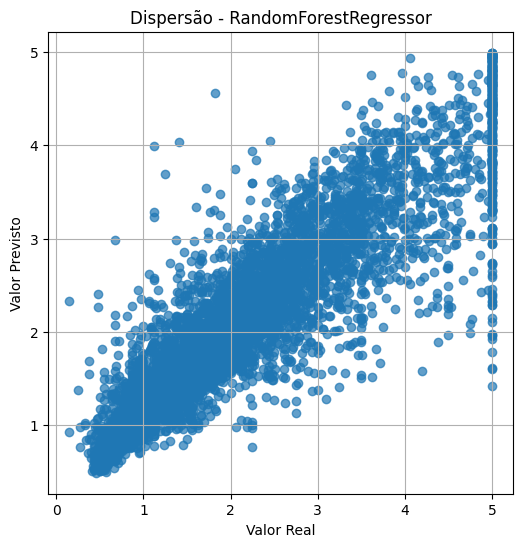


Modelo: RandomForest (California Housing)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.496433   0.334188   0.814883
std     0.009408   0.004724   0.006042
min     0.478749   0.326000   0.800940
25%     0.489326   0.330264   0.810350
50%     0.495526   0.334624   0.815942
75%     0.502181   0.336581   0.819842
max     0.523939   0.348737   0.822863


In [23]:
res_rf_c = run_regression_experiment(X_california, y_california, train_random_forest_regressor, plot=pl, experimento=ex)
regression_results['California_RandomForest'] = res_rf_c
print('\nModelo: RandomForest (California Housing)')
print(res_rf_c.describe())

##### MLPRegressor (Rede Neural Multicamadas)

In [ ]:
res_mlp_c = run_regression_experiment(X_california, y_california, train_mlp_regressor, plot=pl, experimento=ex)
regression_results['California_MLP'] = res_mlp_c
print('\nModelo: MLPRegressor (California Housing)')
print(res_mlp_c.describe())

##### SVR (Support Vector Regressor)

Médias das métricas:
 RMSE    0.976873
MAE     0.752418
R2      0.260624
dtype: float64

Desvio padrão das métricas:
 RMSE    0.177446
MAE     0.147211
R2      0.267196
dtype: float64


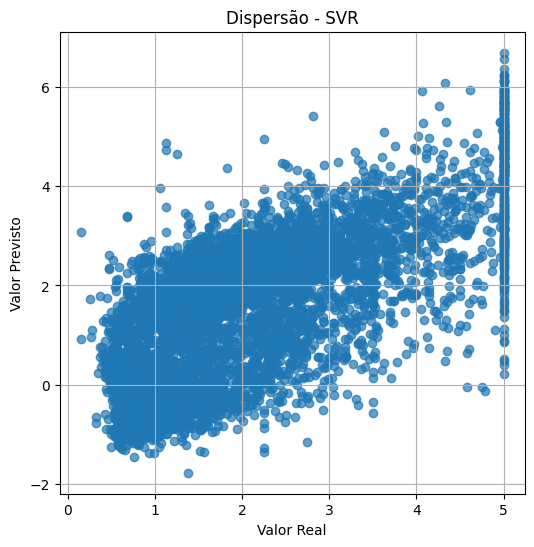


Modelo: SVR (California Housing)
            RMSE        MAE         R2
count  30.000000  30.000000  30.000000
mean    0.976873   0.752418   0.260624
std     0.177446   0.147211   0.267196
min     0.722093   0.535453  -0.342444
25%     0.850324   0.649461   0.057140
50%     0.954107   0.745706   0.316521
75%     1.125441   0.869898   0.454881
max     1.331887   1.045118   0.612511


In [ ]:
res_svr_c = run_regression_experiment(X_california, y_california, train_svr, plot=pl, experimento=ex)
regression_results['California_SVR'] = res_svr_c
print('\nModelo: SVR (California Housing)')
print(res_svr_c.describe())


## Experimento 02 - Classificação Multiclasse

In [ ]:
# Experimentos de Classificação
classification_results = {}
plot = True

### Setup 1 - Wine Quality Dataset

In [ ]:
ex = 'wine_quality'

#### Regressão Logística

In [ ]:
res_log_wine = run_classification_experiment(X_wine, y_wine, train_logistic_regression, plot=pl, experimento=ex)
classification_results['Wine_LogisticRegression'] = res_log_wine
print('\nModelo: LogisticRegression (Wine Quality)')
print(res_log_wine.describe())

NameError: name 'run_classification_experiment' is not defined

#### Random Forest Classifier

Médias das métricas:
 Acuracia    0.694792
F1-score    0.676881
Kappa       0.501410
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.026137
F1-score    0.027284
Kappa       0.040019
dtype: float64


<Figure size 600x600 with 0 Axes>

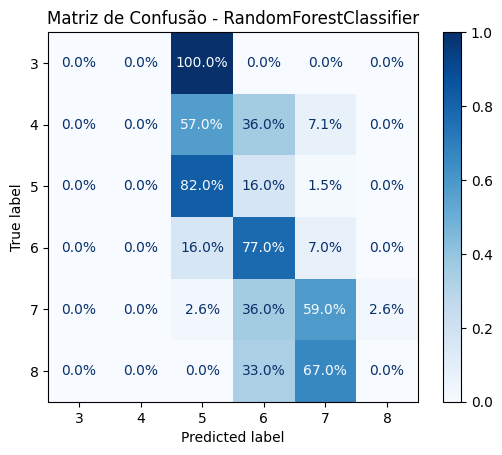


Modelo: RandomForest (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.694792   0.676881   0.501410
std     0.026137   0.027284   0.040019
min     0.640625   0.612930   0.426979
25%     0.682031   0.663546   0.472464
50%     0.695312   0.681147   0.505882
75%     0.712500   0.694834   0.520023
max     0.737500   0.721885   0.564710


In [ ]:
res_rf_wine = run_classification_experiment(X_wine, y_wine, train_random_forest_classifier, plot=pl, experimento=ex)
classification_results['Wine_RandomForest'] = res_rf_wine
print('\nModelo: RandomForest (Wine Quality)')
print(res_rf_wine.describe())

#### MLPClassifier (Rede Neural Multicamadas)

Médias das métricas:
 Acuracia    0.613854
F1-score    0.594981
Kappa       0.367560
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.024820
F1-score    0.026440
Kappa       0.039046
dtype: float64


<Figure size 600x600 with 0 Axes>

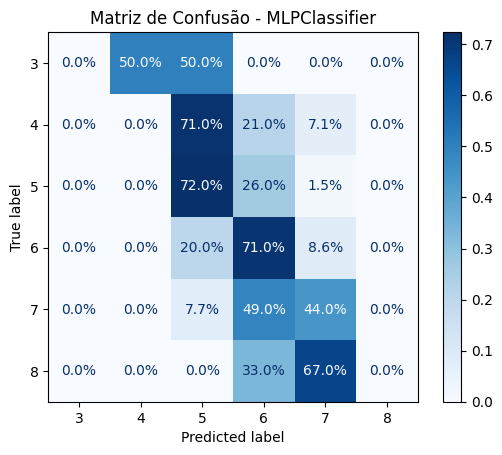


Modelo: MLPClassifier (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.613854   0.594981   0.367560
std     0.024820   0.026440   0.039046
min     0.565625   0.536718   0.300387
25%     0.597656   0.576294   0.336837
50%     0.610938   0.591166   0.368791
75%     0.631250   0.614235   0.388237
max     0.671875   0.653498   0.456697


In [ ]:
res_mlp_wine = run_classification_experiment(X_wine, y_wine, train_mlp_classifier, plot=pl, experimento=ex)
classification_results['Wine_MLP'] = res_mlp_wine
print('\nModelo: MLPClassifier (Wine Quality)')
print(res_mlp_wine.describe())

#### SVM Classifier (Support Vector Machine)

Médias das métricas:
 Acuracia    0.608750
F1-score    0.580545
Kappa       0.345207
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.022955
F1-score    0.025860
Kappa       0.034777
dtype: float64


<Figure size 600x600 with 0 Axes>

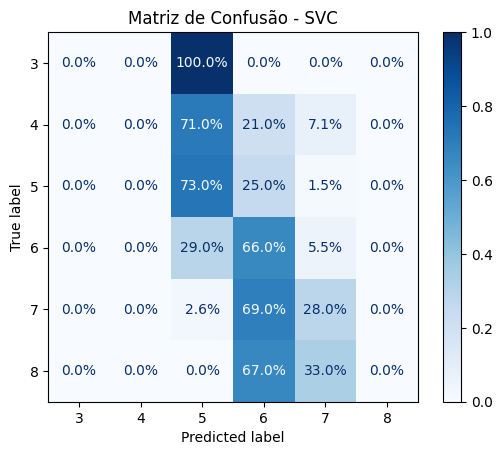


Modelo: SVMClassifier (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.608750   0.580545   0.345207
std     0.022955   0.025860   0.034777
min     0.556250   0.515687   0.274458
25%     0.597656   0.568427   0.322741
50%     0.604688   0.580417   0.340471
75%     0.625000   0.597239   0.364133
max     0.650000   0.627285   0.414348


In [ ]:
res_svm_wine = run_classification_experiment(X_wine, y_wine, train_svm_classifier, plot=pl, experimento=ex)
classification_results['Wine_SVM'] = res_svm_wine
print('\nModelo: SVMClassifier (Wine Quality)')
print(res_svm_wine.describe())

### Setup 2 -  Iris Dataset

In [ ]:
ex = 'iris'

#### Regressão Logística

Médias das métricas:
 Acuracia    0.918889
F1-score    0.918758
Kappa       0.876090
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.062320
F1-score    0.062799
Kappa       0.094343
dtype: float64


<Figure size 600x600 with 0 Axes>

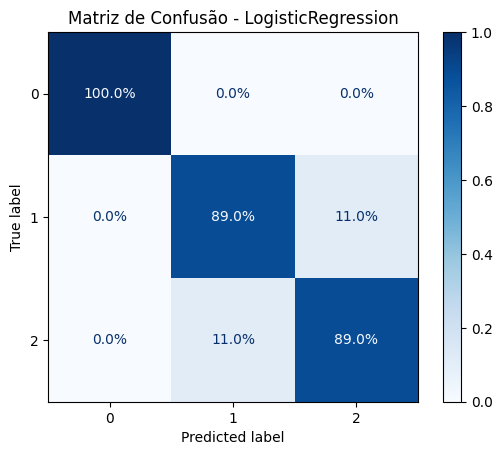


Modelo: LogisticRegression (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.918889   0.918758   0.876090
std     0.062320   0.062799   0.094343
min     0.766667   0.764000   0.643463
25%     0.900000   0.900192   0.847908
50%     0.933333   0.933333   0.898819
75%     0.966667   0.966869   0.948623
max     1.000000   1.000000   1.000000


In [ ]:
res_log_iris = run_classification_experiment(X_iris, y_iris, train_logistic_regression, plot=pl, experimento=ex)
classification_results['Iris_LogisticRegression'] = res_log_iris
print('\nModelo: LogisticRegression (Iris)')
print(res_log_iris.describe())

#### Random Forest Classifier

Médias das métricas:
 Acuracia    0.950000
F1-score    0.949665
Kappa       0.923019
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.042661
F1-score    0.043650
Kappa       0.065938
dtype: float64


<Figure size 600x600 with 0 Axes>

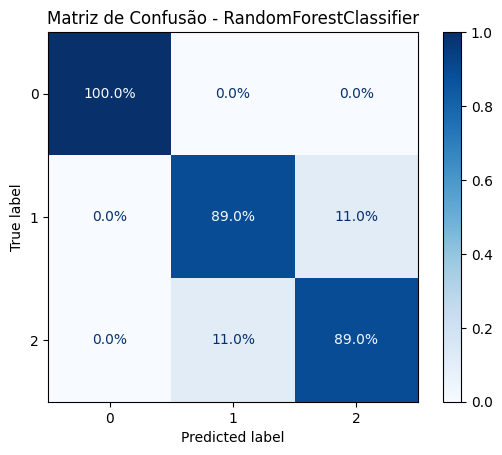


Modelo: RandomForest (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.950000   0.949665   0.923019
std     0.042661   0.043650   0.065938
min     0.833333   0.823362   0.741379
25%     0.933333   0.933106   0.897956
50%     0.966667   0.966399   0.947552
75%     0.966667   0.967192   0.949854
max     1.000000   1.000000   1.000000


In [ ]:
res_rf_iris = run_classification_experiment(X_iris, y_iris, train_random_forest_classifier, plot=pl, experimento=ex)
classification_results['Iris_RandomForest'] = res_rf_iris
print('\nModelo: RandomForest (Iris)')
print(res_rf_iris.describe())

#### MLPClassifier (Rede Neural Multicamadas)

Médias das métricas:
 Acuracia    0.952222
F1-score    0.952061
Kappa       0.925642
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.037837
F1-score    0.038024
Kappa       0.060373
dtype: float64


<Figure size 600x600 with 0 Axes>

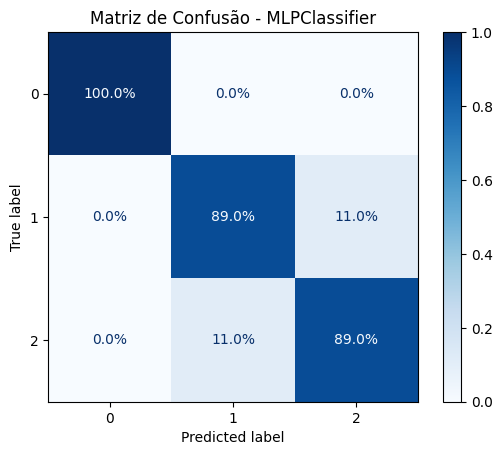


Modelo: MLPClassifier (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.952222   0.952061   0.925642
std     0.037837   0.038024   0.060373
min     0.866667   0.866667   0.772727
25%     0.933333   0.933333   0.898990
50%     0.966667   0.966560   0.948141
75%     0.966667   0.967078   0.949854
max     1.000000   1.000000   1.000000


In [ ]:
res_mlp_iris = run_classification_experiment(X_iris, y_iris, train_mlp_classifier, plot=pl, experimento=ex)
classification_results['Iris_MLP'] = res_mlp_iris
print('\nModelo: MLPClassifier (Iris)')
print(res_mlp_iris.describe())

#### SVM Classifier (Support Vector Machine)

Médias das métricas:
 Acuracia    0.952222
F1-score    0.952104
Kappa       0.926495
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.038837
F1-score    0.039164
Kappa       0.059604
dtype: float64


<Figure size 600x600 with 0 Axes>

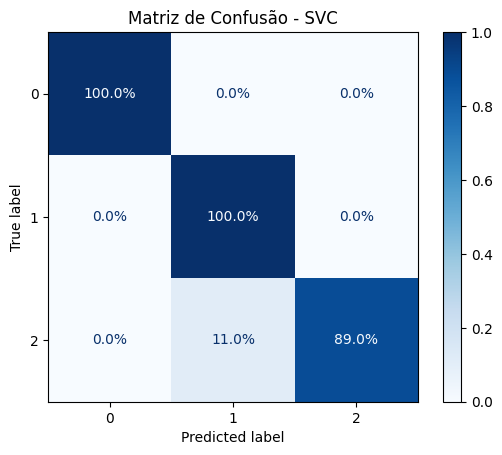


Modelo: SVMClassifier (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.952222   0.952104   0.926495
std     0.038837   0.039164   0.059604
min     0.866667   0.862271   0.794521
25%     0.933333   0.933106   0.897956
50%     0.966667   0.966399   0.947735
75%     0.966667   0.967207   0.949495
max     1.000000   1.000000   1.000000


In [ ]:

res_svm_iris = run_classification_experiment(X_iris, y_iris, train_svm_classifier, plot=pl, experimento=ex)
classification_results['Iris_SVM'] = res_svm_iris
print('\nModelo: SVMClassifier (Iris)')
print(res_svm_iris.describe())

## Experimento 03 - Classificação Multiclasse - Balanceado

In [ ]:
# Experimentos de Classificação
classification_results_b = {}
plot = True

### Setup 1 - Wine Quality Dataset

In [ ]:
ex = 'wine_quality_balanced'

#### Regressão Logística

Médias das métricas:
 Acuracia    0.516748
F1-score    0.504472
Kappa       0.420085
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.018956
F1-score    0.019322
Kappa       0.022724
dtype: float64


<Figure size 600x600 with 0 Axes>

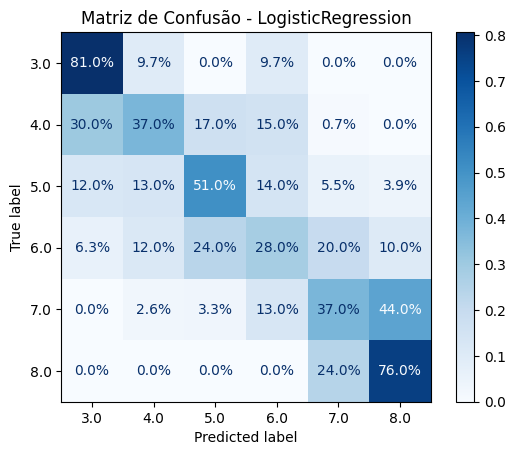


Modelo: LogisticRegression (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.516748   0.504472   0.420085
std     0.018956   0.019322   0.022724
min     0.484108   0.472777   0.380108
25%     0.501222   0.488367   0.402137
50%     0.518949   0.503525   0.423416
75%     0.529951   0.517848   0.435500
max     0.550122   0.540223   0.460558


In [ ]:
res_log_wine = run_classification_experiment(X_wine_b, y_wine_b, train_logistic_regression, plot=pl, experimento=ex)
classification_results_b['Wine_LogisticRegression'] = res_log_wine
print('\nModelo: LogisticRegression (Wine Quality)')
print(res_log_wine.describe())

#### Random Forest Classifier

Médias das métricas:
 Acuracia    0.947840
F1-score    0.947289
Kappa       0.937359
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.007123
F1-score    0.007219
Kappa       0.008548
dtype: float64


<Figure size 600x600 with 0 Axes>

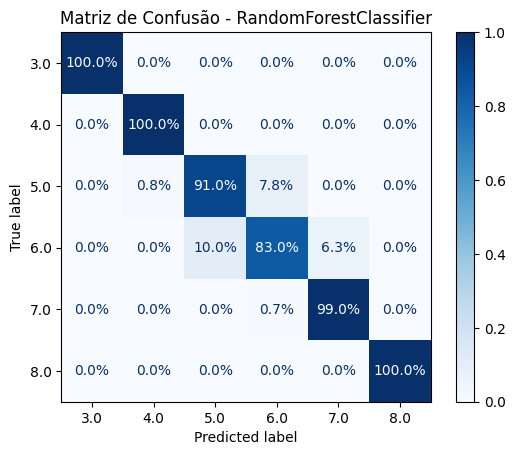


Modelo: RandomForest (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.947840   0.947289   0.937359
std     0.007123   0.007219   0.008548
min     0.932763   0.932440   0.919240
25%     0.943765   0.942898   0.932447
50%     0.947433   0.946735   0.936870
75%     0.951100   0.950718   0.941301
max     0.963325   0.963193   0.955939


In [ ]:
res_rf_wine = run_classification_experiment(X_wine_b, y_wine_b, train_random_forest_classifier, plot=pl, experimento=ex)
classification_results_b['Wine_RandomForest'] = res_rf_wine
print('\nModelo: RandomForest (Wine Quality)')
print(res_rf_wine.describe())

#### MLPClassifier (Rede Neural Multicamadas)

Médias das métricas:
 Acuracia    0.758272
F1-score    0.750709
Kappa       0.709770
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.016598
F1-score    0.016620
Kappa       0.019862
dtype: float64


<Figure size 600x600 with 0 Axes>

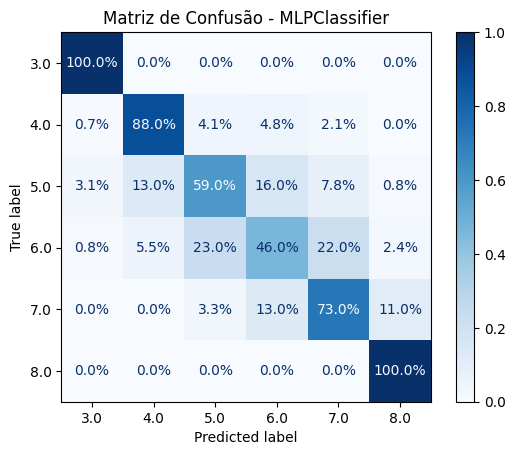


Modelo: MLPClassifier (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.758272   0.750709   0.709770
std     0.016598   0.016620   0.019862
min     0.727384   0.720081   0.672761
25%     0.749694   0.742337   0.699559
50%     0.760391   0.752406   0.712212
75%     0.768032   0.759041   0.721747
max     0.793399   0.790193   0.751956


In [ ]:
res_mlp_wine = run_classification_experiment(X_wine_b, y_wine_b, train_mlp_classifier, plot=pl, experimento=ex)
classification_results_b['Wine_MLP'] = res_mlp_wine
print('\nModelo: MLPClassifier (Wine Quality)')
print(res_mlp_wine.describe())

#### SVM Classifier (Support Vector Machine)

Médias das métricas:
 Acuracia    0.608750
F1-score    0.580545
Kappa       0.345207
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.022955
F1-score    0.025860
Kappa       0.034777
dtype: float64


<Figure size 600x600 with 0 Axes>

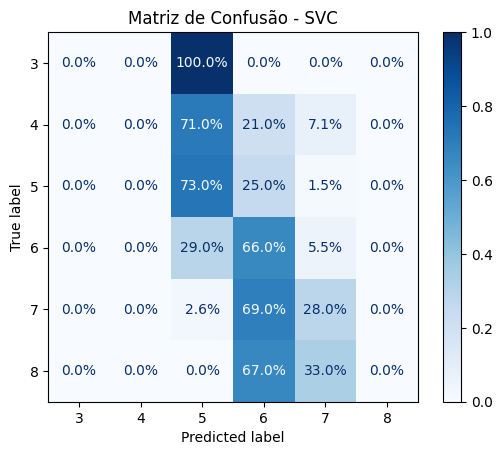


Modelo: SVMClassifier (Wine Quality)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.608750   0.580545   0.345207
std     0.022955   0.025860   0.034777
min     0.556250   0.515687   0.274458
25%     0.597656   0.568427   0.322741
50%     0.604688   0.580417   0.340471
75%     0.625000   0.597239   0.364133
max     0.650000   0.627285   0.414348


In [ ]:
res_svm_wine = run_classification_experiment(X_wine, y_wine, train_svm_classifier, plot=pl, experimento=ex)
classification_results_b['Wine_SVM'] = res_svm_wine
print('\nModelo: SVMClassifier (Wine Quality)')
print(res_svm_wine.describe())

### Setup 2 -  Iris Dataset

In [ ]:
ex = 'iris_balanced'

#### Regressão Logística

Médias das métricas:
 Acuracia    0.918889
F1-score    0.918758
Kappa       0.876090
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.062320
F1-score    0.062799
Kappa       0.094343
dtype: float64


<Figure size 600x600 with 0 Axes>

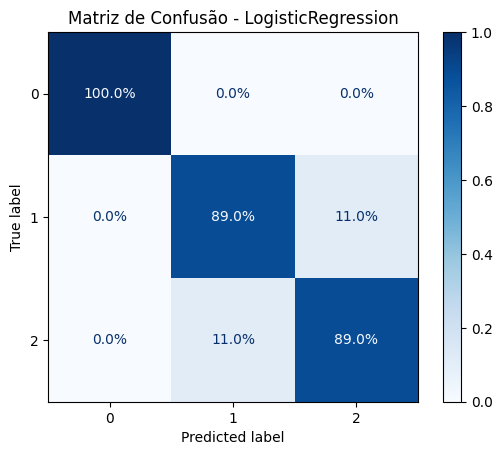


Modelo: LogisticRegression (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.918889   0.918758   0.876090
std     0.062320   0.062799   0.094343
min     0.766667   0.764000   0.643463
25%     0.900000   0.900192   0.847908
50%     0.933333   0.933333   0.898819
75%     0.966667   0.966869   0.948623
max     1.000000   1.000000   1.000000


In [ ]:
res_log_iris = run_classification_experiment(X_iris, y_iris, train_logistic_regression, plot=pl, experimento=ex)
classification_results_b['Iris_LogisticRegression'] = res_log_iris
print('\nModelo: LogisticRegression (Iris)')
print(res_log_iris.describe())

#### Random Forest Classifier

Médias das métricas:
 Acuracia    0.945556
F1-score    0.945396
Kappa       0.916120
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.041507
F1-score    0.041872
Kappa       0.064134
dtype: float64


<Figure size 600x600 with 0 Axes>

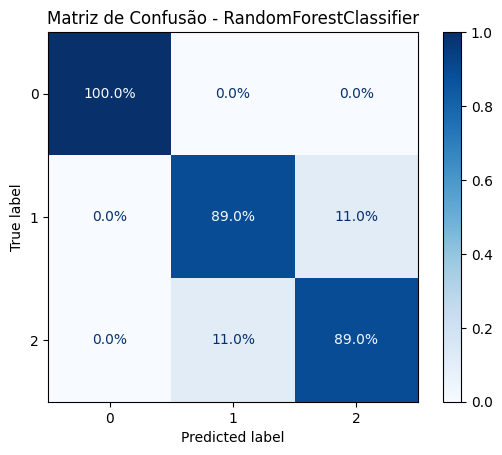


Modelo: RandomForest (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.945556   0.945396   0.916120
std     0.041507   0.041872   0.064134
min     0.866667   0.862271   0.794521
25%     0.933333   0.933030   0.890315
50%     0.950000   0.950346   0.923776
75%     0.966667   0.966966   0.949495
max     1.000000   1.000000   1.000000


In [ ]:
res_rf_iris = run_classification_experiment(X_iris, y_iris, train_random_forest_classifier, plot=pl, experimento=ex)
classification_results_b['Iris_RandomForest'] = res_rf_iris
print('\nModelo: RandomForest (Iris)')
print(res_rf_iris.describe())

#### MLPClassifier (Rede Neural Multicamadas)

Médias das métricas:
 Acuracia    0.954444
F1-score    0.954343
Kappa       0.929371
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.034445
F1-score    0.034559
Kappa       0.053828
dtype: float64


<Figure size 600x600 with 0 Axes>

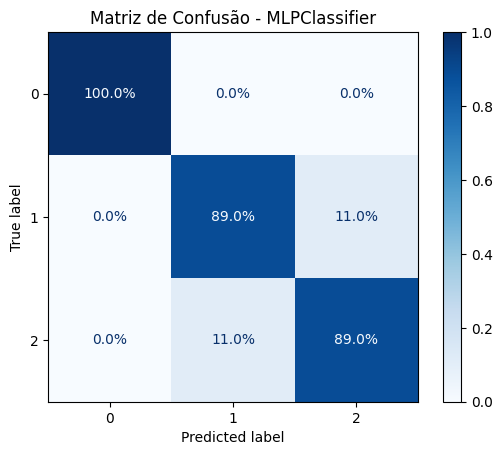


Modelo: MLPClassifier (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.954444   0.954343   0.929371
std     0.034445   0.034559   0.053828
min     0.866667   0.866667   0.795222
25%     0.933333   0.933333   0.898990
50%     0.966667   0.966560   0.948141
75%     0.966667   0.967078   0.949854
max     1.000000   1.000000   1.000000


In [ ]:
res_mlp_iris = run_classification_experiment(X_iris, y_iris, train_mlp_classifier, plot=pl, experimento=ex)
classification_results_b['Iris_MLP'] = res_mlp_iris
print('\nModelo: MLPClassifier (Iris)')
print(res_mlp_iris.describe())

#### SVM Classifier (Support Vector Machine)

Médias das métricas:
 Acuracia    0.952222
F1-score    0.952104
Kappa       0.926495
dtype: float64

Desvio padrão das métricas:
 Acuracia    0.038837
F1-score    0.039164
Kappa       0.059604
dtype: float64


<Figure size 600x600 with 0 Axes>

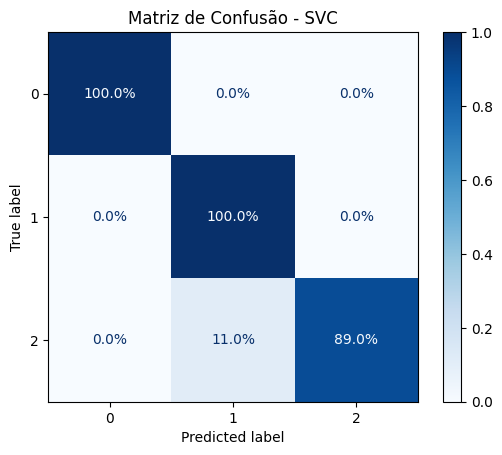


Modelo: SVMClassifier (Iris)
        Acuracia   F1-score      Kappa
count  30.000000  30.000000  30.000000
mean    0.952222   0.952104   0.926495
std     0.038837   0.039164   0.059604
min     0.866667   0.862271   0.794521
25%     0.933333   0.933106   0.897956
50%     0.966667   0.966399   0.947735
75%     0.966667   0.967207   0.949495
max     1.000000   1.000000   1.000000


In [ ]:

res_svm_iris = run_classification_experiment(X_iris, y_iris, train_svm_classifier, plot=pl, experimento=ex)
classification_results_b['Iris_SVM'] = res_svm_iris
print('\nModelo: SVMClassifier (Iris)')
print(res_svm_iris.describe())

## Análise dos Resultados
Serão apresentados gráficos comparativos das métricas dos modelos para cada base de dados.

### Gráficos comparativos das métricas dos modelos

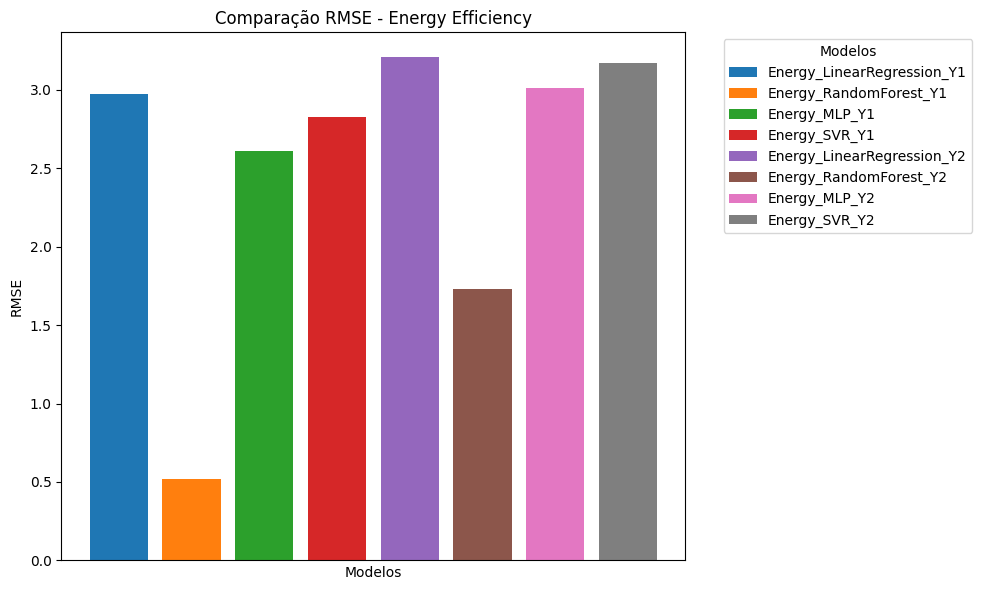

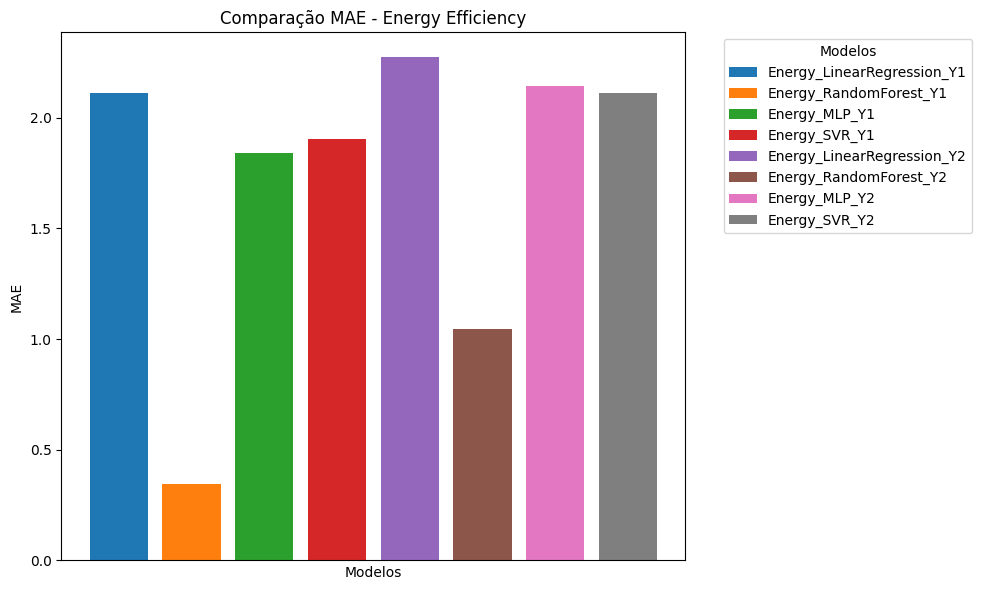

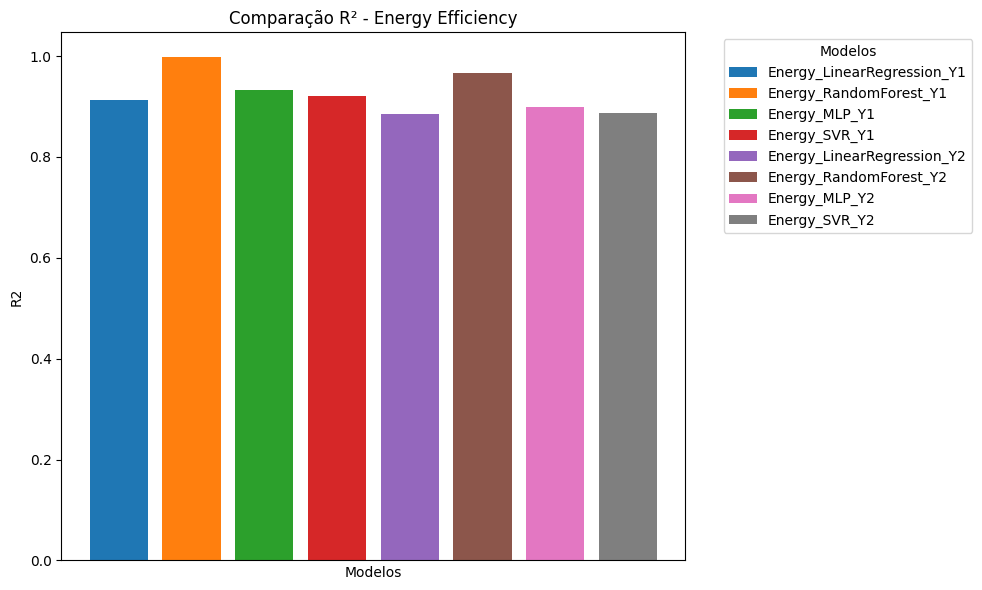

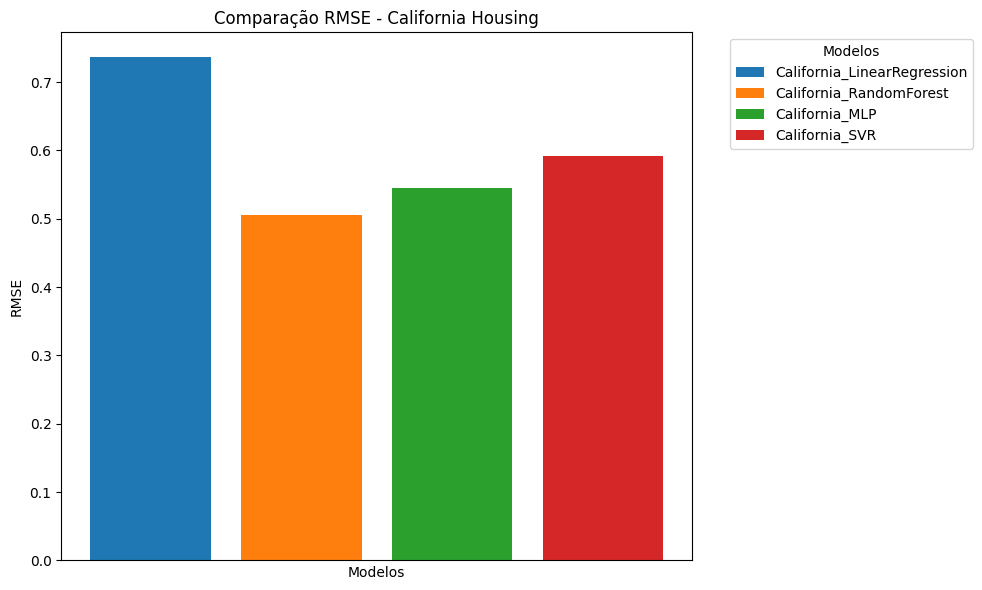

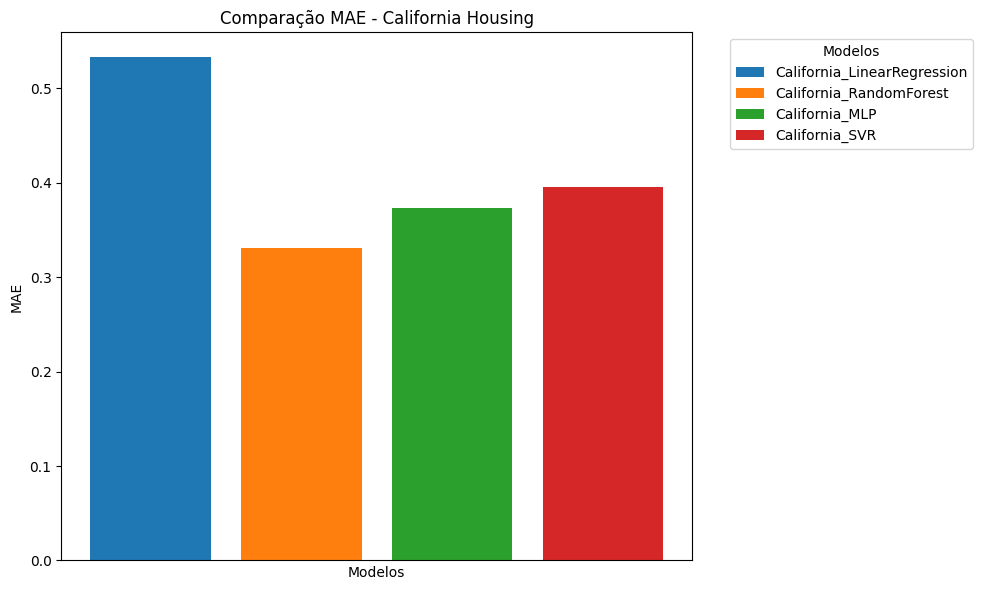

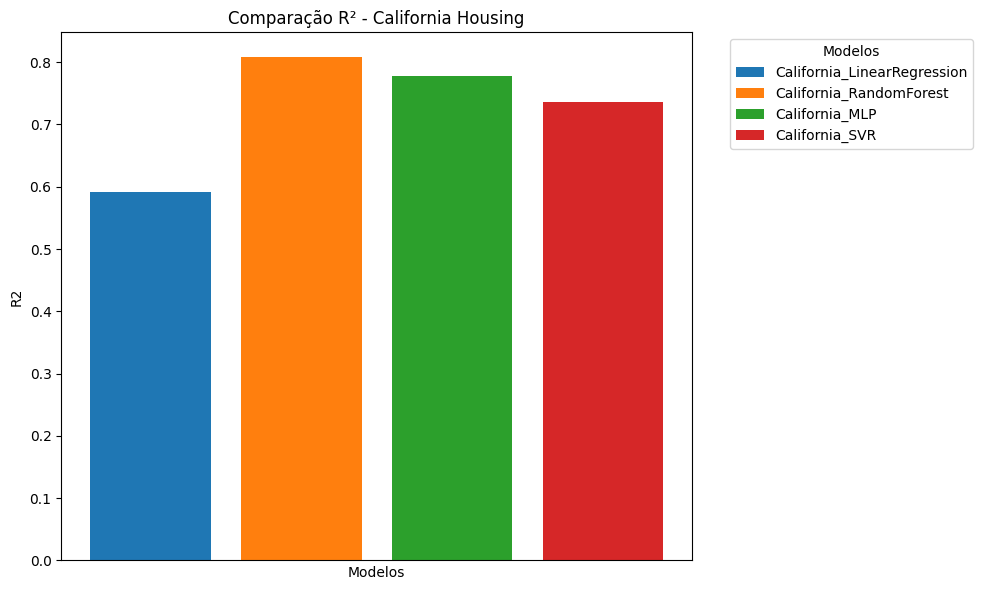

Resultados SEM balanceamento:


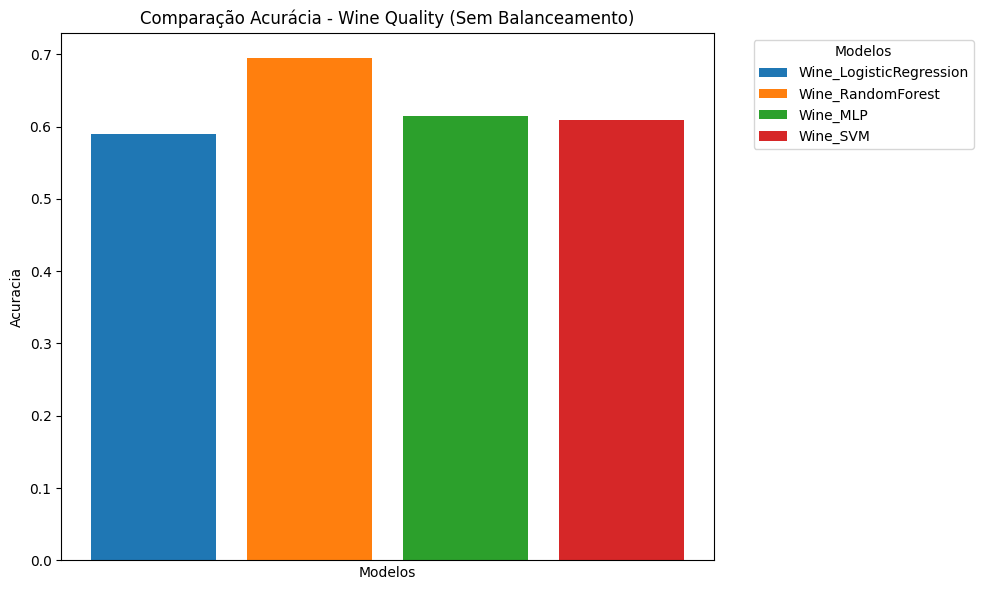

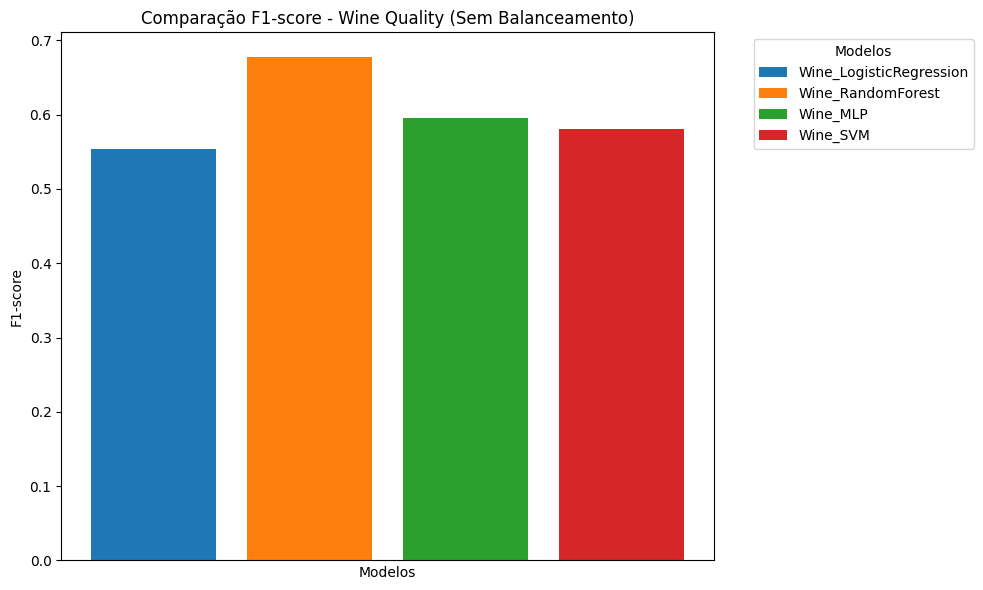

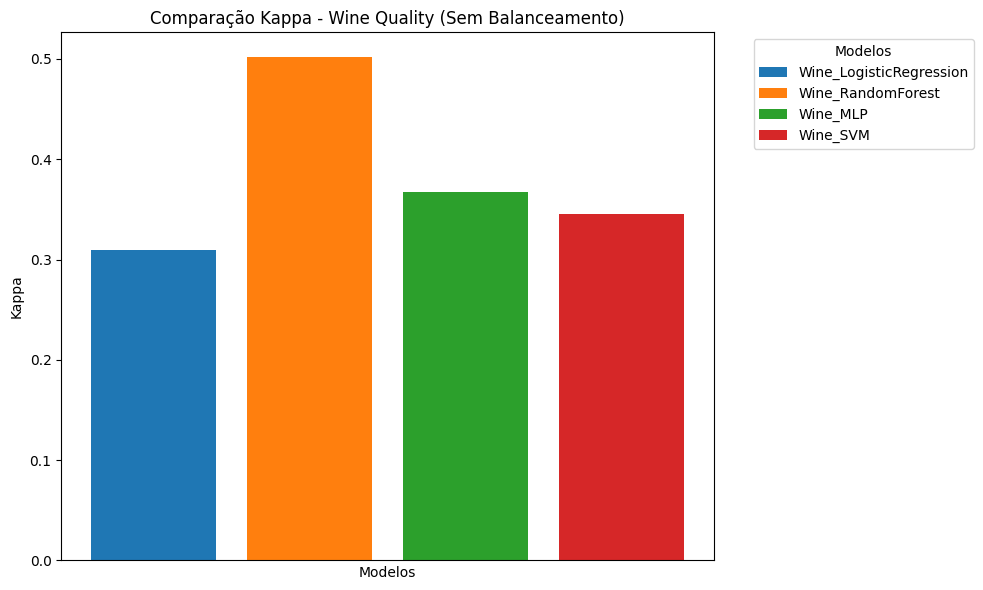

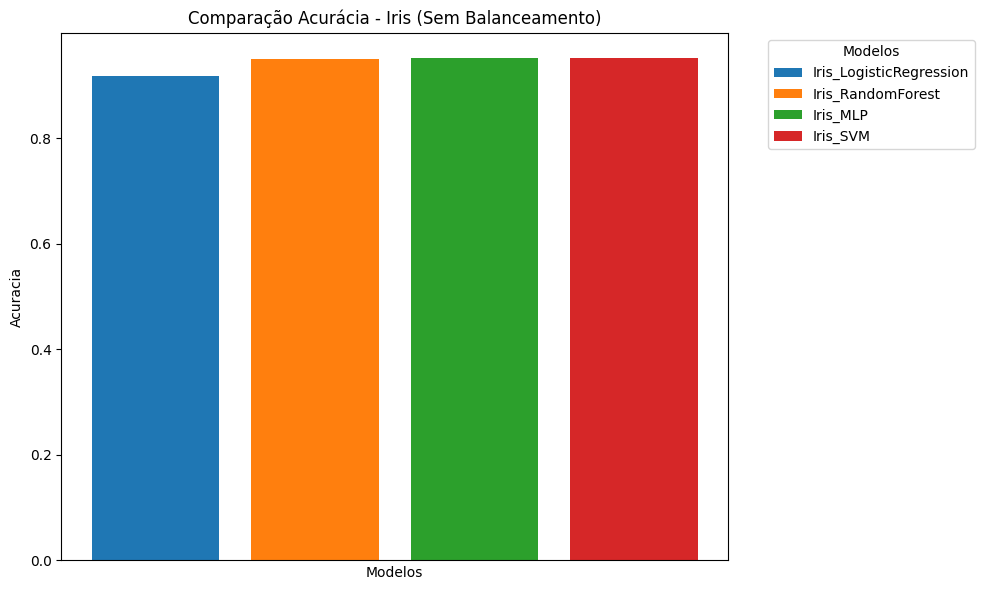

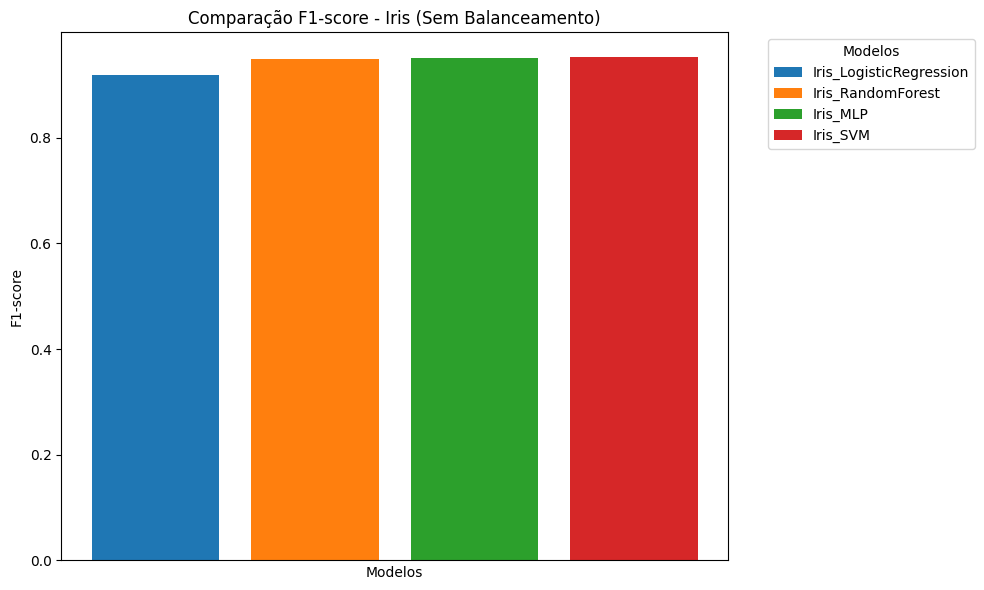

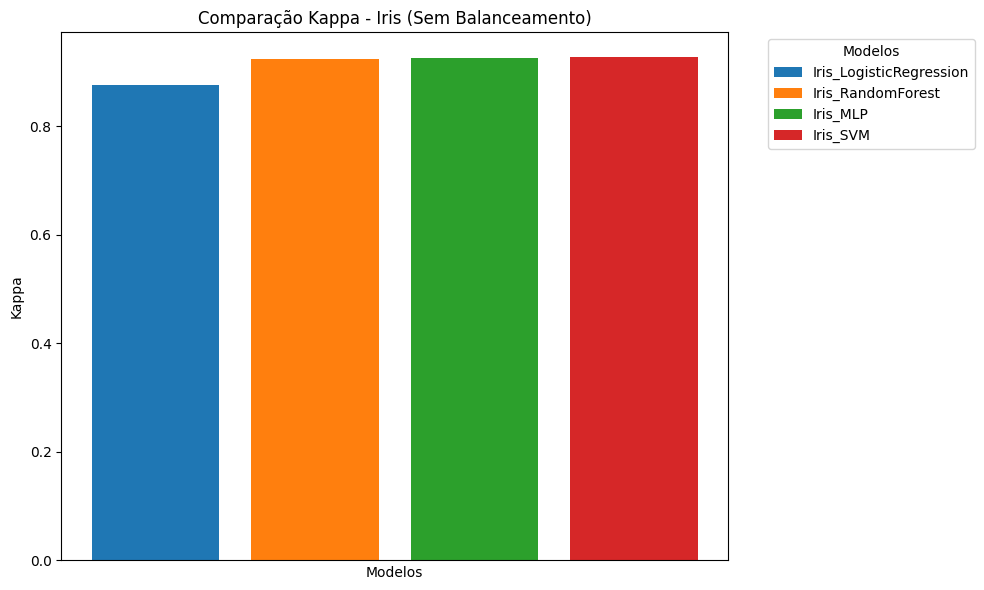

Resultados COM balanceamento:


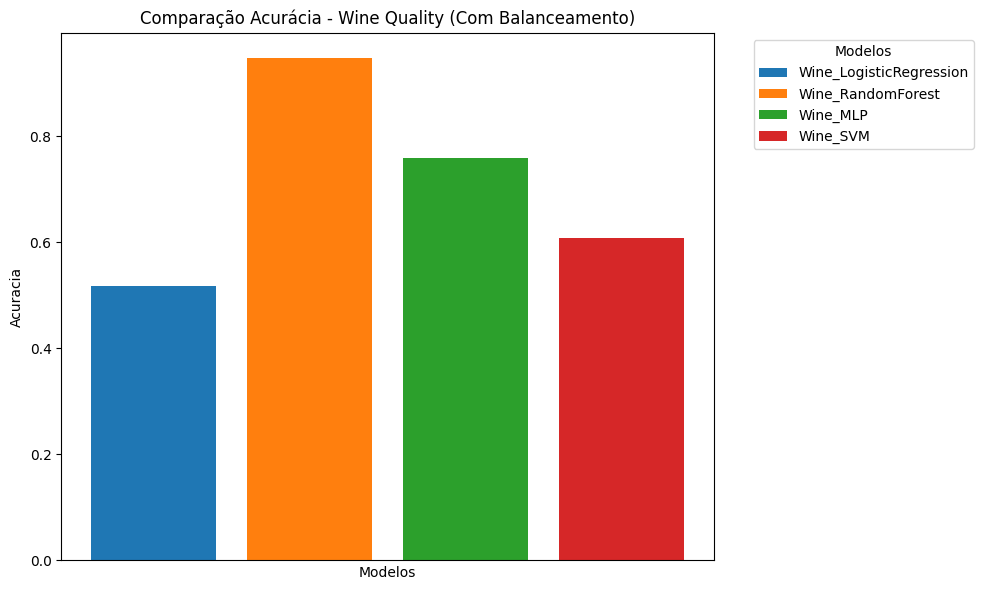

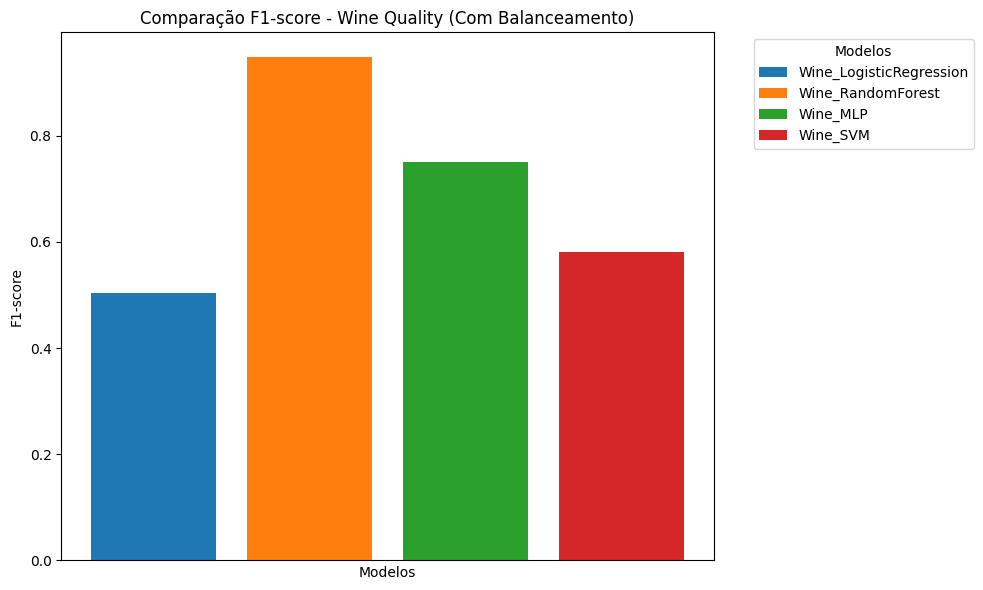

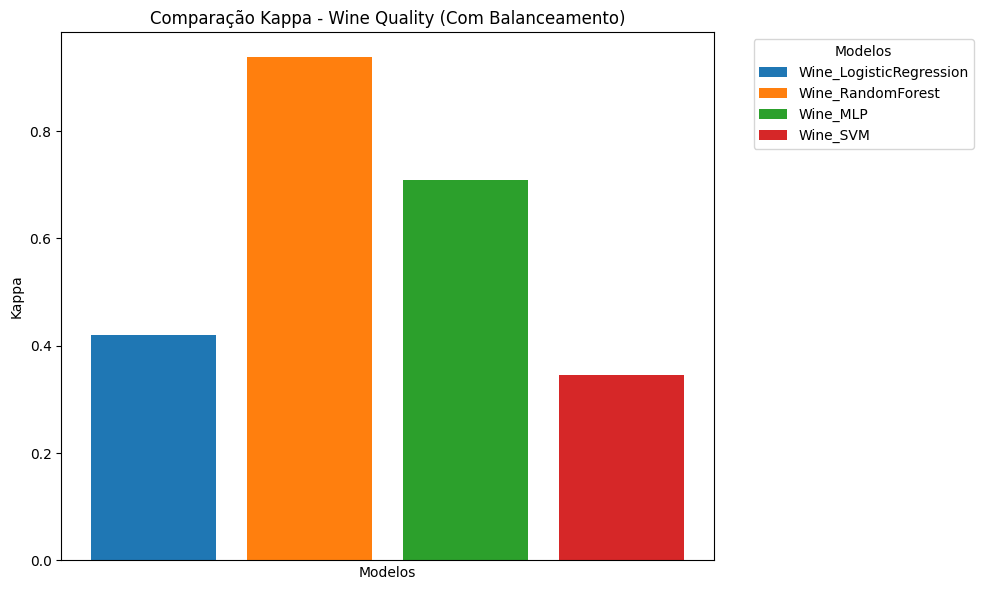

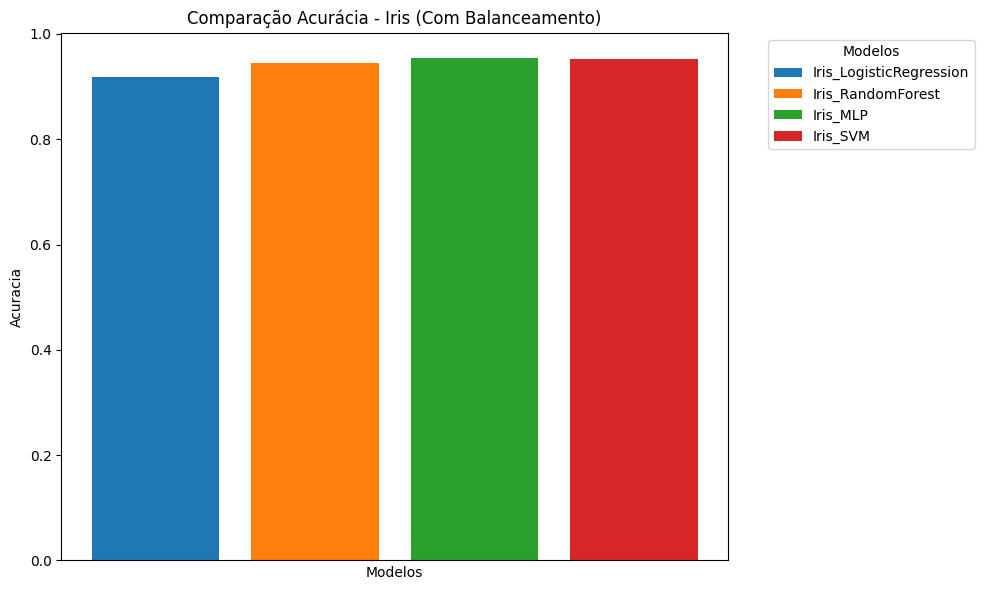

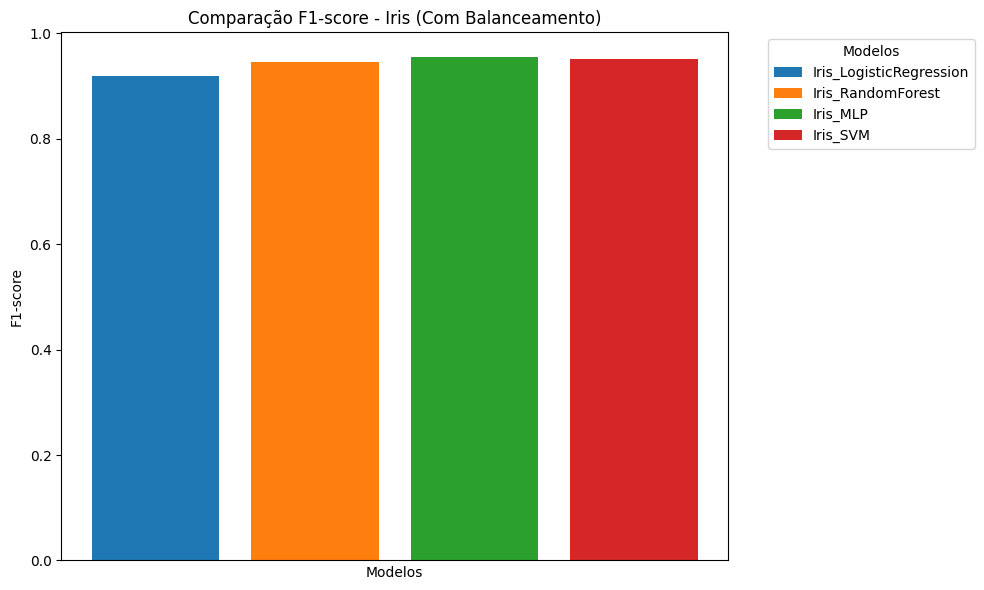

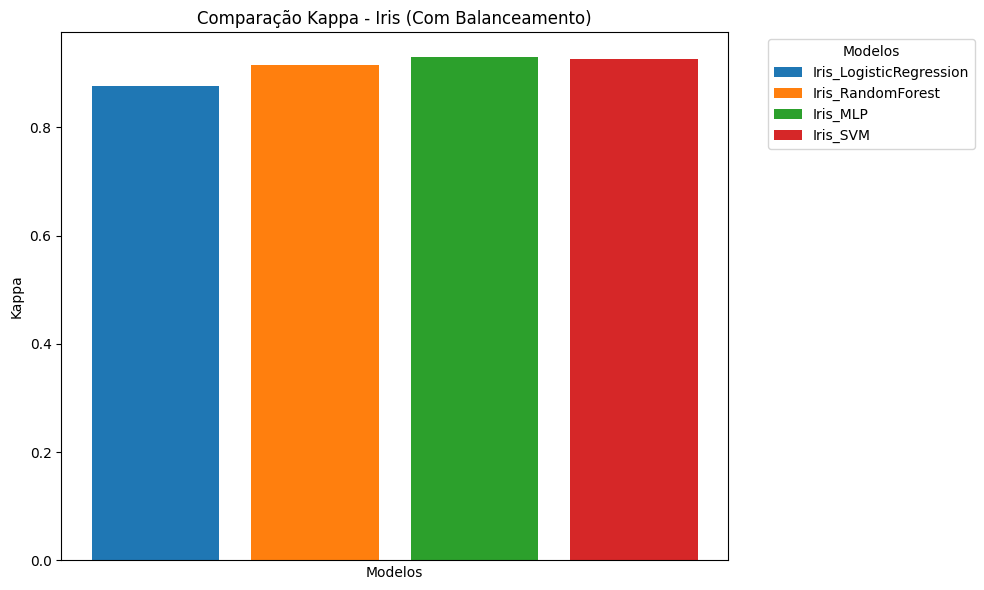

In [ ]:

def plot_metric_comparison(results_dict, metric, title, filename):
    plt.figure(figsize=(10,6))
    bars = []
    labels = []
    for key, df in results_dict.items():
        if metric in df.columns:
            bar = plt.bar(key, df[metric].mean(), label=key)
            bars.append(bar)
            labels.append(key)
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks([])  # Remove os valores do eixo x
    plt.gca().set_xlabel("Modelos")  # Remove o nome do eixo x
    plt.legend(labels, title="Modelos", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'graficos/{filename}.png', bbox_inches='tight')
    plt.show()

# --- Gráficos de regressão por dataset ---

# Energy Efficiency
energy_results = {k: v for k, v in regression_results.items() if "Energy" in k}
plot_metric_comparison(energy_results, 'RMSE', 'Comparação RMSE - Energy Efficiency', 'comparacao_rmse_energy')
plot_metric_comparison(energy_results, 'MAE', 'Comparação MAE - Energy Efficiency', 'comparacao_mae_energy')
plot_metric_comparison(energy_results, 'R2', 'Comparação R² - Energy Efficiency', 'comparacao_r2_energy')

# California Housing
california_results = {k: v for k, v in regression_results.items() if "California" in k}
plot_metric_comparison(california_results, 'RMSE', 'Comparação RMSE - California Housing', 'comparacao_rmse_california')
plot_metric_comparison(california_results, 'MAE', 'Comparação MAE - California Housing', 'comparacao_mae_california')
plot_metric_comparison(california_results, 'R2', 'Comparação R² - California Housing', 'comparacao_r2_california')

# --- Gráficos de classificação por dataset ---

# SEM BALANCEAMENTO
print("Resultados SEM balanceamento:")

# Wine Quality
wine_results = {k: v for k, v in classification_results.items() if "Wine" in k}
plot_metric_comparison(wine_results, 'Acuracia', 'Comparação Acurácia - Wine Quality (Sem Balanceamento)', 'comparacao_acuracia_wine_sem_balanceamento')
plot_metric_comparison(wine_results, 'F1-score', 'Comparação F1-score - Wine Quality (Sem Balanceamento)', 'comparacao_f1_wine_sem_balanceamento')
plot_metric_comparison(wine_results, 'Kappa', 'Comparação Kappa - Wine Quality (Sem Balanceamento)', 'comparacao_kappa_wine_sem_balanceamento')

# Iris
iris_results = {k: v for k, v in classification_results.items() if "Iris" in k}
plot_metric_comparison(iris_results, 'Acuracia', 'Comparação Acurácia - Iris (Sem Balanceamento)', 'comparacao_acuracia_iris_sem_balanceamento')
plot_metric_comparison(iris_results, 'F1-score', 'Comparação F1-score - Iris (Sem Balanceamento)', 'comparacao_f1_iris_sem_balanceamento')
plot_metric_comparison(iris_results, 'Kappa', 'Comparação Kappa - Iris (Sem Balanceamento)', 'comparacao_kappa_iris_sem_balanceamento')

# COM BALANCEAMENTO
print("Resultados COM balanceamento:")

# Wine Quality
wine_results_b = {k: v for k, v in classification_results_b.items() if "Wine" in k}
plot_metric_comparison(wine_results_b, 'Acuracia', 'Comparação Acurácia - Wine Quality (Com Balanceamento)', 'comparacao_acuracia_wine_com_balanceamento')
plot_metric_comparison(wine_results_b, 'F1-score', 'Comparação F1-score - Wine Quality (Com Balanceamento)', 'comparacao_f1_wine_com_balanceamento')
plot_metric_comparison(wine_results_b, 'Kappa', 'Comparação Kappa - Wine Quality (Com Balanceamento)', 'comparacao_kappa_wine_com_balanceamento')

# Iris
iris_results_b = {k: v for k, v in classification_results_b.items() if "Iris" in k}
plot_metric_comparison(iris_results_b, 'Acuracia', 'Comparação Acurácia - Iris (Com Balanceamento)', 'comparacao_acuracia_iris_com_balanceamento')
plot_metric_comparison(iris_results_b, 'F1-score', 'Comparação F1-score - Iris (Com Balanceamento)', 'comparacao_f1_iris_com_balanceamento')
plot_metric_comparison(iris_results_b, 'Kappa', 'Comparação Kappa - Iris (Com Balanceamento)', 'comparacao_kappa_iris_com_balanceamento')

### Print dos Resultados

In [ ]:
print('Resultados de Regressão:')
for key, df in regression_results.items():
    print(f"{key} - RMSE: {df['RMSE'].mean():.4f}, MAE: {df['MAE'].mean():.4f}, R2: {df['R2'].mean():.4f}")
print('Resultados de Classificação sem balanciamento:')
for key, df in classification_results.items():
    print(f"{key} - Acurácia: {df['Acuracia'].mean():.4f}, F1-score: {df['F1-score'].mean():.4f}, Kappa: {df['Kappa'].mean():.4f}")

print('Resultados de Classificação com balanciamento:')
for key, df in classification_results_b.items():
    print(f"{key} - Acurácia: {df['Acuracia'].mean():.4f}, F1-score: {df['F1-score'].mean():.4f}, Kappa: {df['Kappa'].mean():.4f}")

Resultados de Regressão:
Energy_LinearRegression_Y1 - RMSE: 2.9708, MAE: 2.1091, R2: 0.9128
Energy_RandomForest_Y1 - RMSE: 0.5187, MAE: 0.3462, R2: 0.9973
Energy_MLP_Y1 - RMSE: 2.6125, MAE: 1.8421, R2: 0.9324
Energy_SVR_Y1 - RMSE: 2.8290, MAE: 1.9028, R2: 0.9210
Energy_LinearRegression_Y2 - RMSE: 3.2059, MAE: 2.2713, R2: 0.8849
Energy_RandomForest_Y2 - RMSE: 1.7285, MAE: 1.0459, R2: 0.9664
Energy_MLP_Y2 - RMSE: 3.0091, MAE: 2.1409, R2: 0.8985
Energy_SVR_Y2 - RMSE: 3.1696, MAE: 2.1104, R2: 0.8875
California_LinearRegression - RMSE: 0.7361, MAE: 0.5327, R2: 0.5918
California_RandomForest - RMSE: 0.5062, MAE: 0.3309, R2: 0.8075
California_MLP - RMSE: 0.5447, MAE: 0.3728, R2: 0.7771
California_SVR - RMSE: 0.5925, MAE: 0.3955, R2: 0.7363
Resultados de Classificação sem balanciamento:
Wine_LogisticRegression - Acurácia: 0.5893, F1-score: 0.5544, Kappa: 0.3096
Wine_RandomForest - Acurácia: 0.6948, F1-score: 0.6769, Kappa: 0.5014
Wine_MLP - Acurácia: 0.6139, F1-score: 0.5950, Kappa: 0.3676
Win

### Plot Boxplot para os Resultados

O boxplot (ou diagrama de caixa) é um gráfico estatístico que resume a distribuição de um conjunto de dados numéricos, facilitando a visualização de sua dispersão, assimetrias e possíveis outliers. Ele é muito útil para comparar o desempenho de diferentes modelos em métricas como RMSE ou F1-score.

Componentes do Boxplot
Caixa (box):
Representa o intervalo entre o primeiro quartil (Q1, 25%) e o terceiro quartil (Q3, 75%) dos dados. Ou seja, 50% dos valores estão dentro da caixa.

Linha central (mediana):
Linha dentro da caixa que indica o valor da mediana (Q2, 50%). Divide os dados ao meio.

Extremidades da caixa (Q1 e Q3):

Q1 (primeiro quartil): 25% dos dados estão abaixo desse valor.
Q3 (terceiro quartil): 75% dos dados estão abaixo desse valor.
"Bigodes" (whiskers):
Se estendem da caixa até o menor e maior valor dentro de 1,5 vezes o intervalo interquartil (IQR = Q3 - Q1) a partir dos quartis.

Limite inferior: Q1 - 1,5 × IQR
Limite superior: Q3 + 1,5 × IQR
Outliers:
Pontos fora dos bigodes são considerados valores atípicos (outliers) e geralmente são plotados como pontos individuais.

Média (opcional):
Em alguns boxplots (como no seu código), a média é mostrada como um ponto ou linha diferente (geralmente em vermelho).

O que o boxplot mostra?
Dispersão:
O tamanho da caixa e o comprimento dos bigodes mostram a variabilidade dos dados.
Assimetria:
Se a mediana não está centralizada na caixa ou se um bigode é maior que o outro, indica assimetria na distribuição.
Comparação entre grupos:
Vários boxplots lado a lado permitem comparar rapidamente a distribuição de diferentes modelos ou experimentos.
Outliers:
Pontos fora dos bigodes indicam execuções com desempenho muito diferente do padrão.
Exemplo prático
No seu notebook, ao plotar o boxplot do F1-score para diferentes modelos de classificação, você pode ver:

Qual modelo tem desempenho mais consistente (caixa menor).
Qual modelo tem maior mediana (melhor desempenho central).
Se algum modelo apresenta outliers (execuções muito ruins ou muito boas).
Resumo:
O boxplot é uma ferramenta visual poderosa para comparar distribuições de métricas entre modelos, mostrando não só o valor central (mediana), mas também a dispersão, assimetria e possíveis outliers dos resultados.

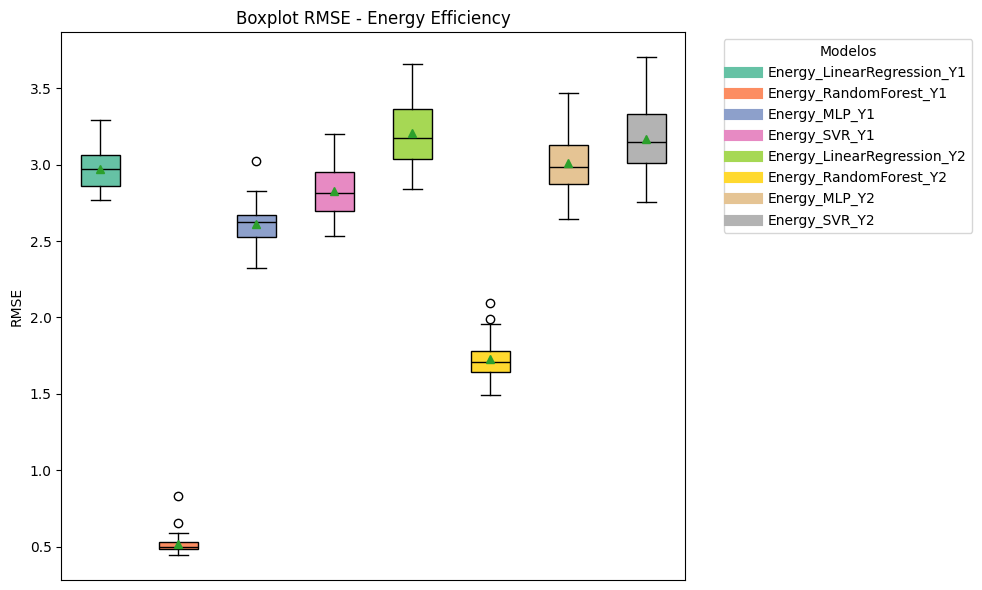

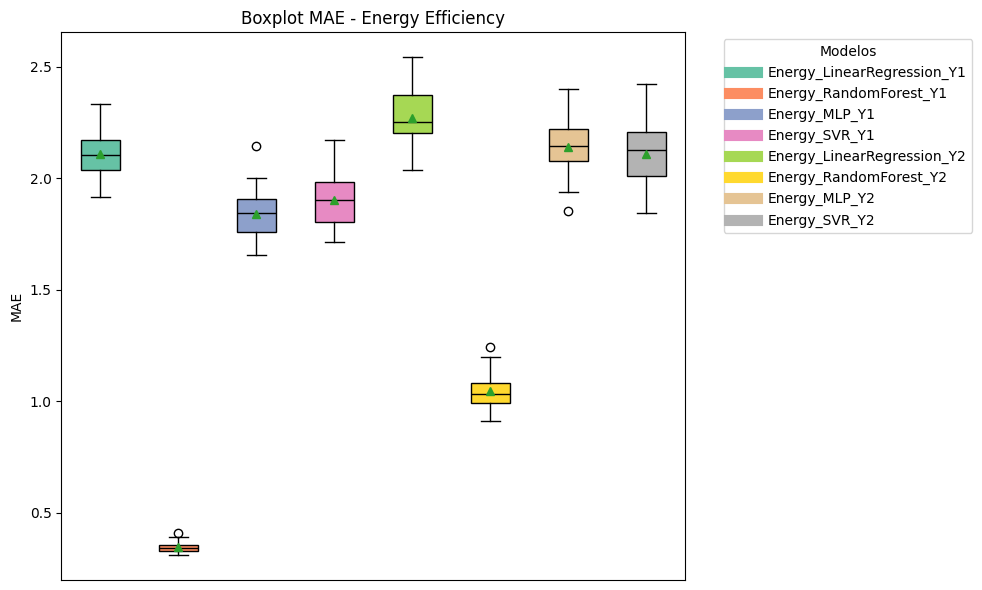

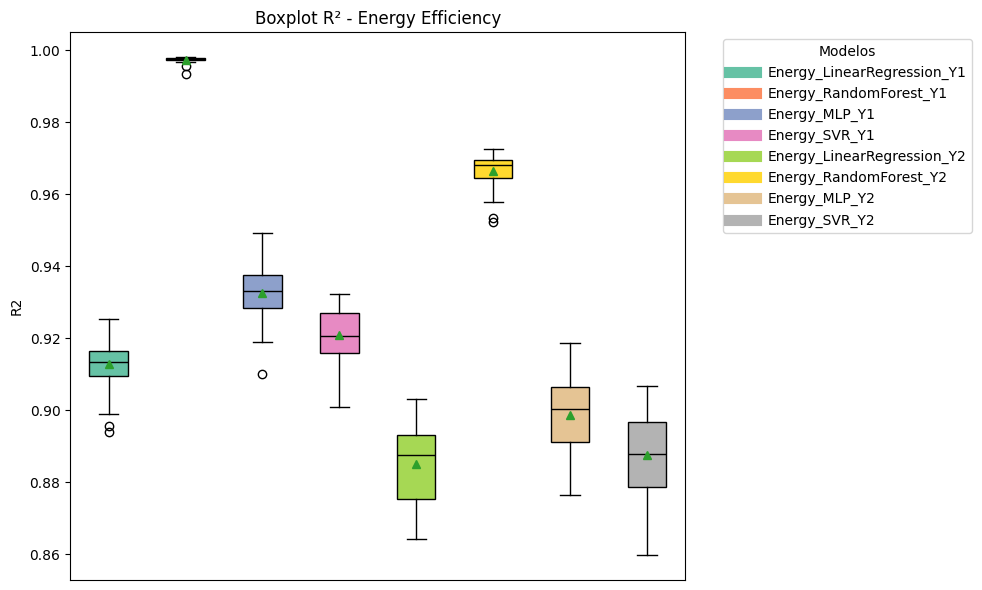

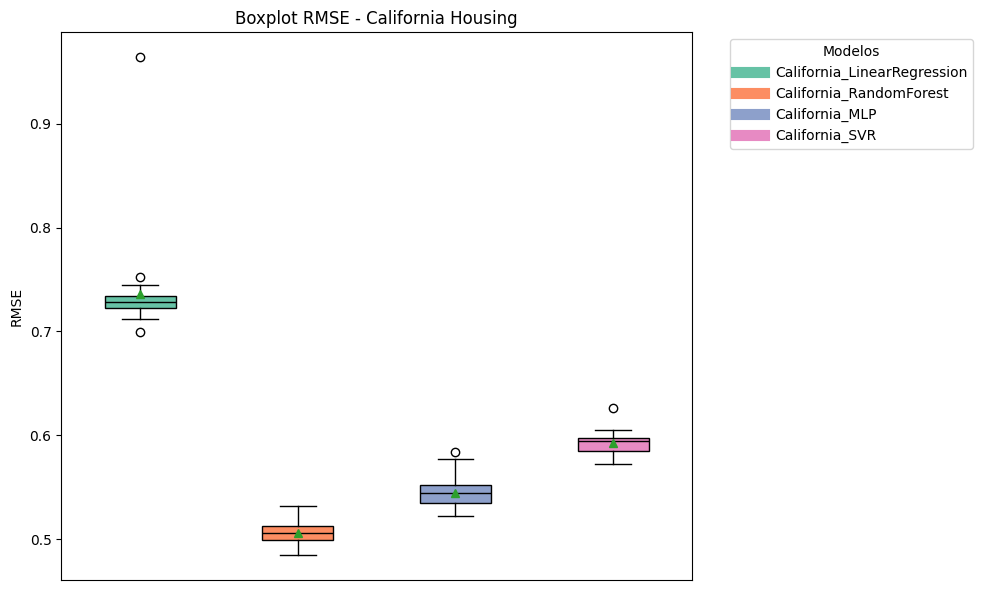

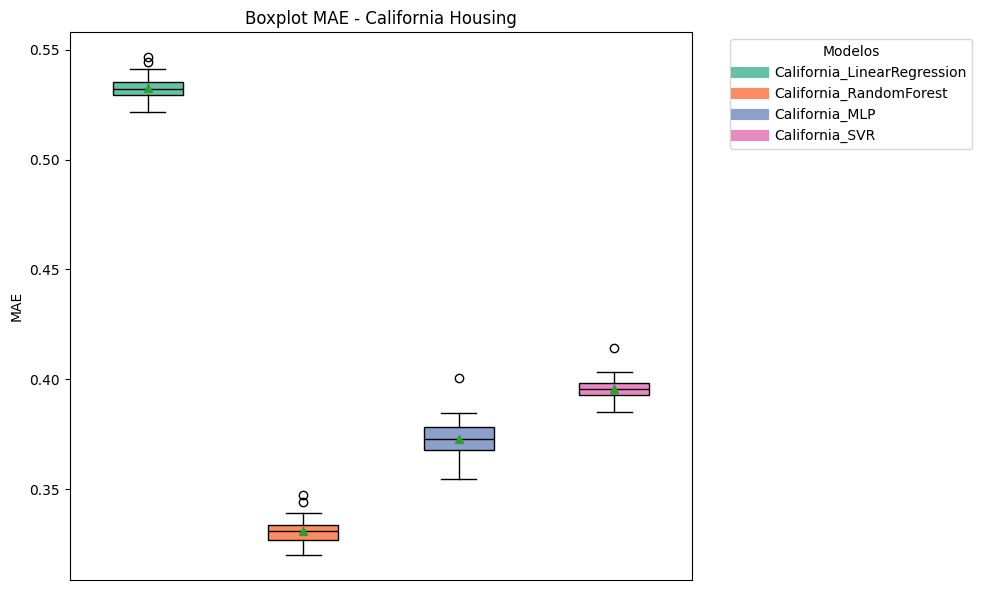

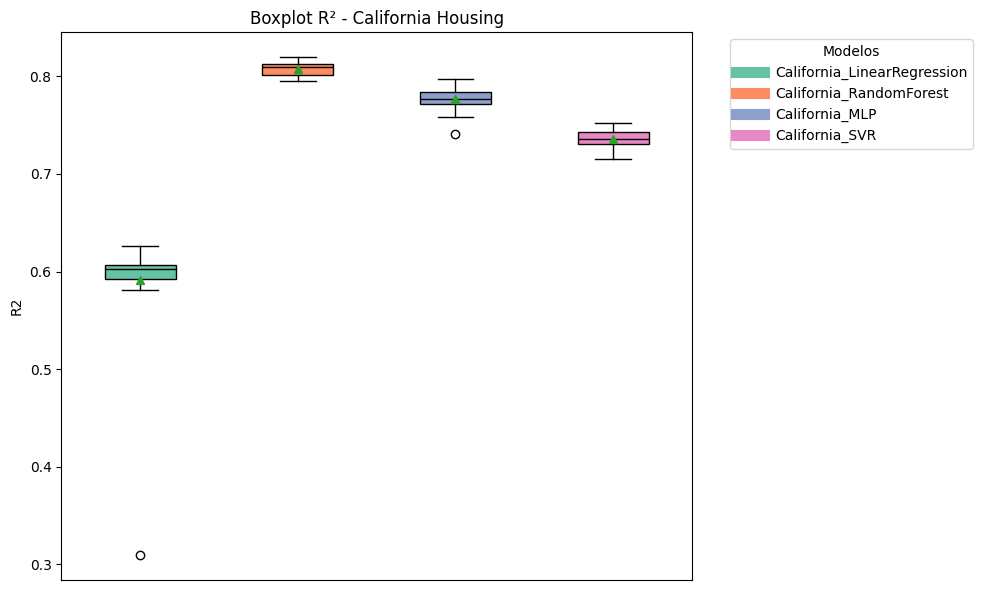

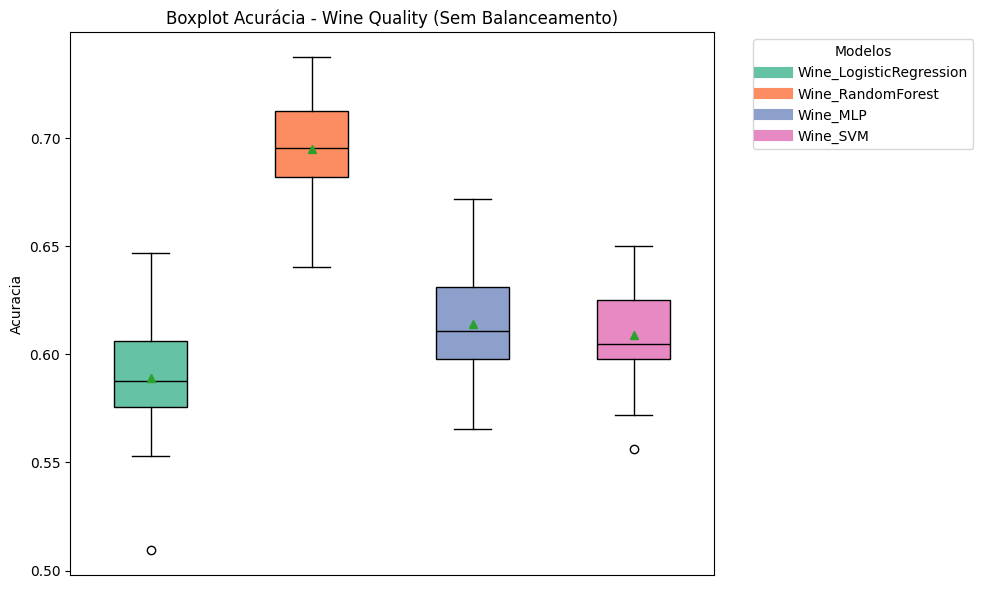

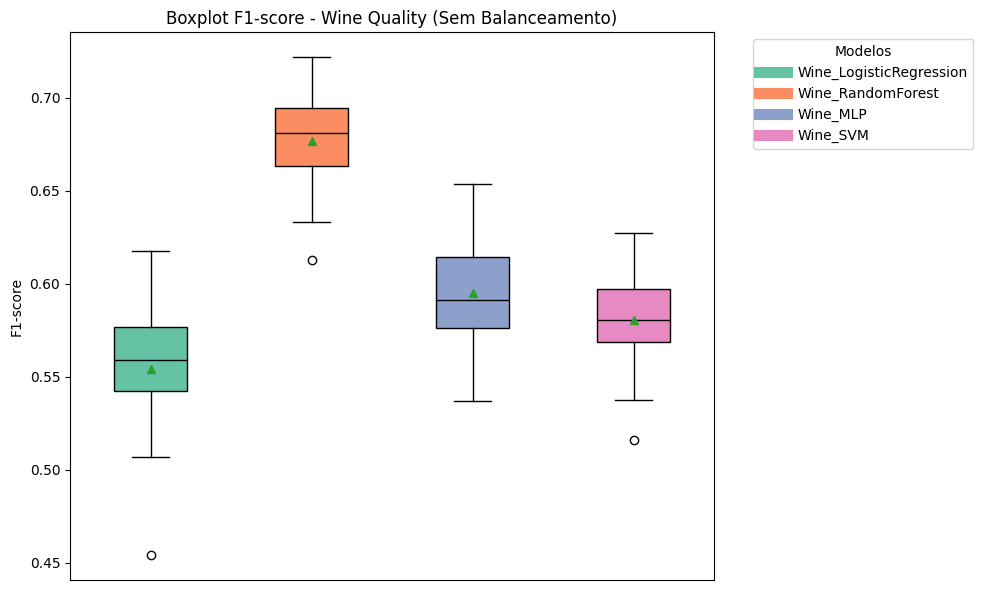

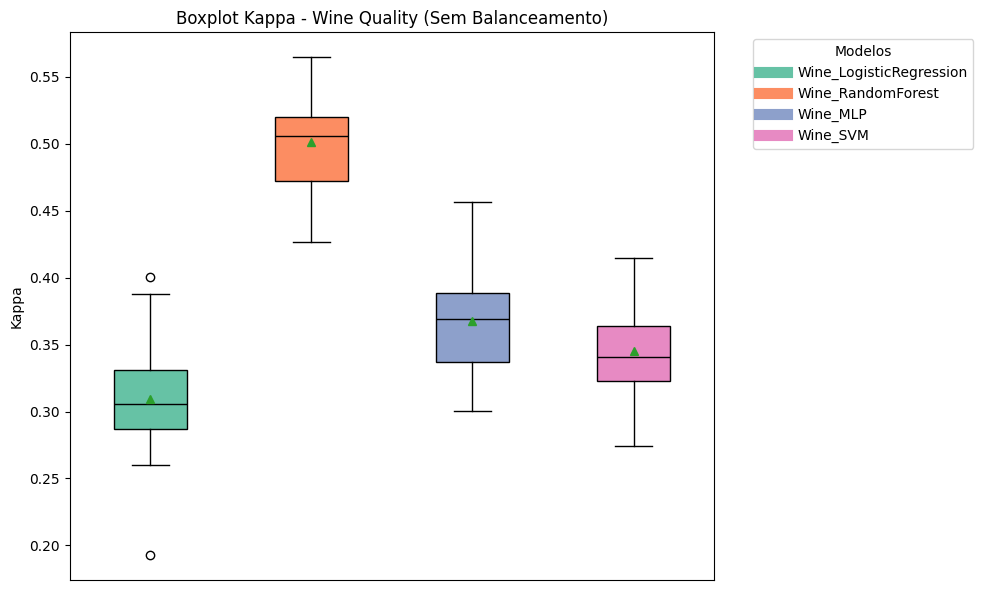

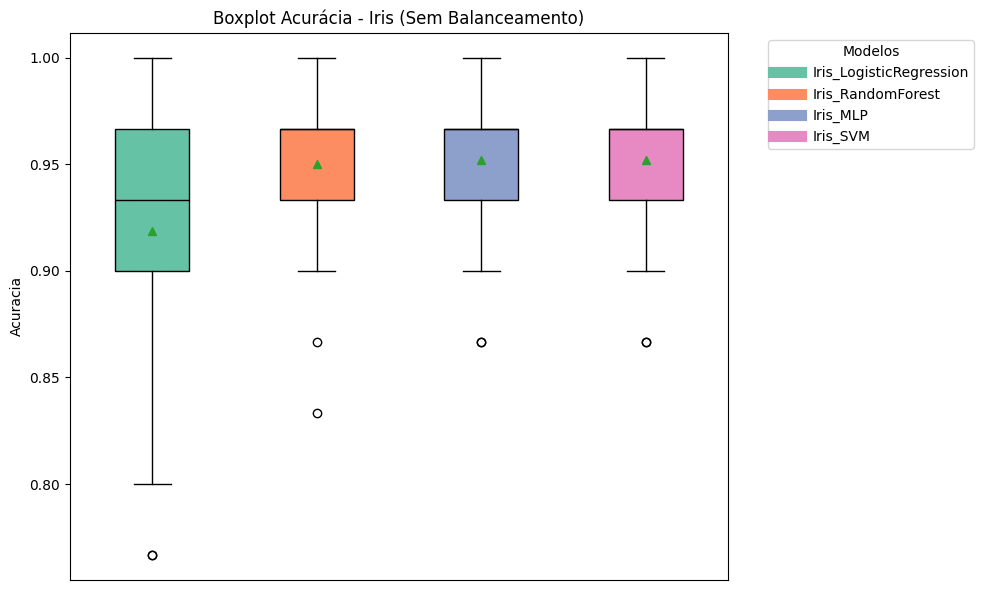

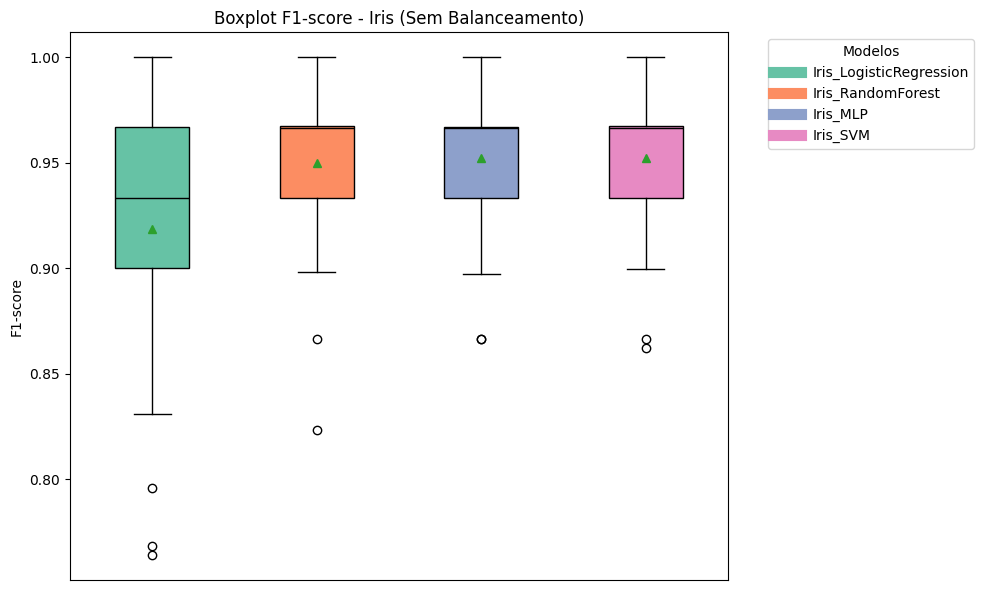

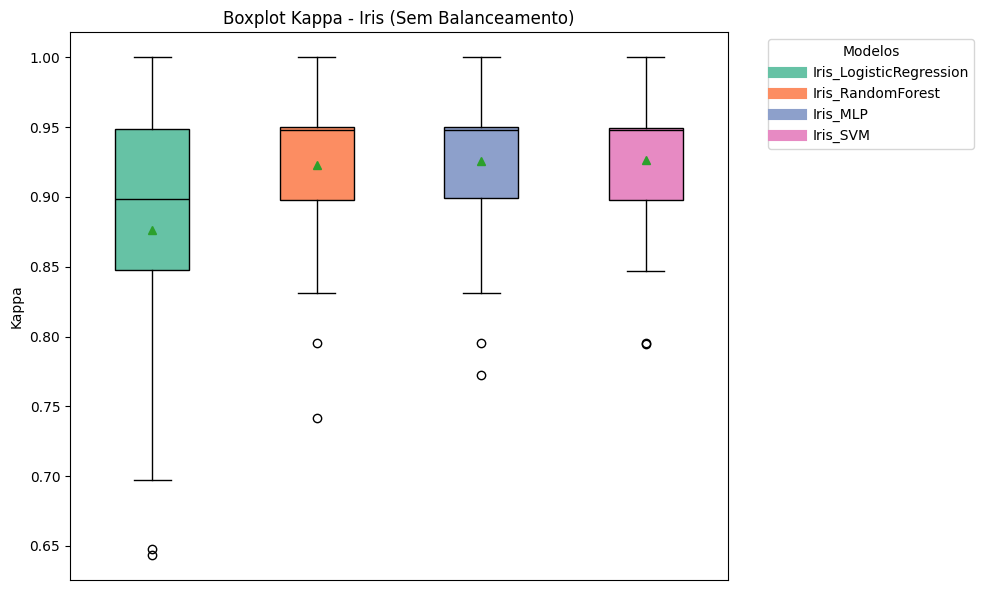

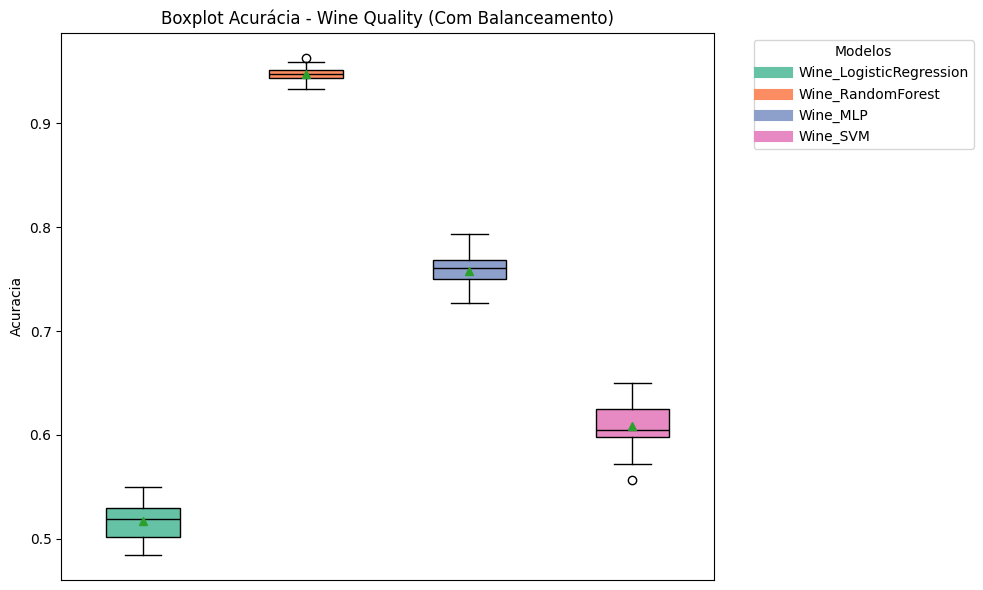

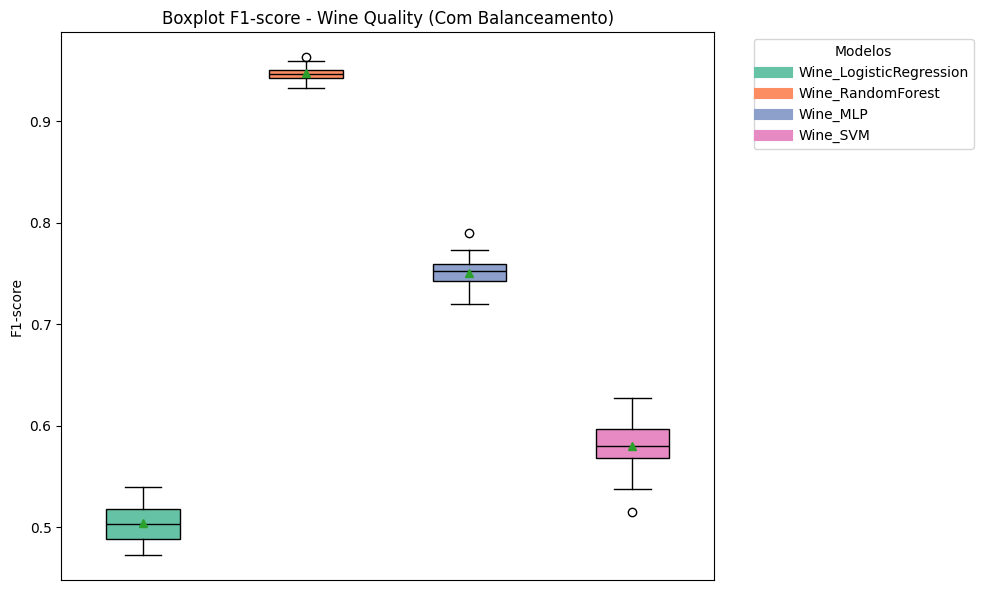

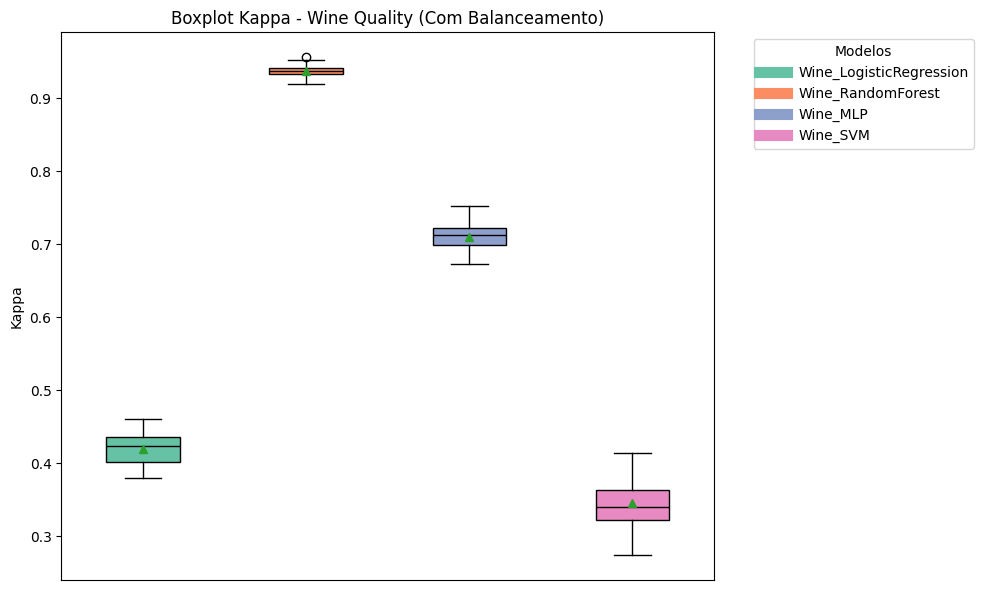

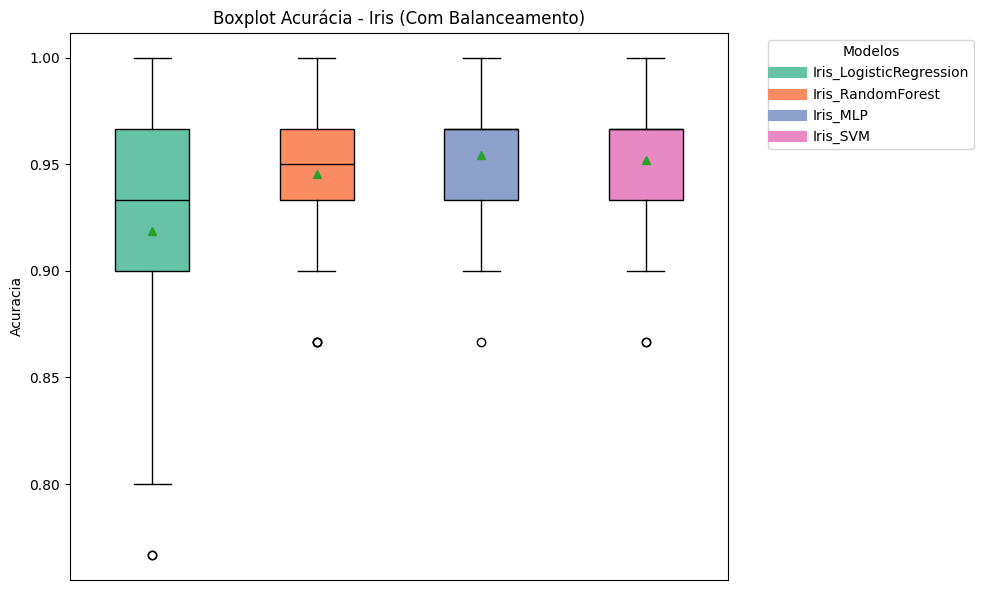

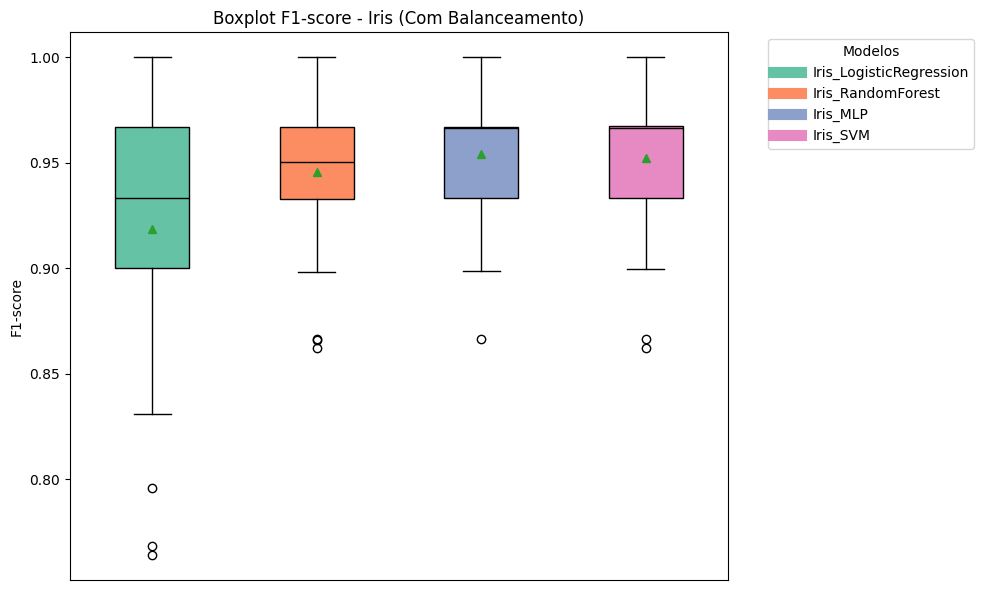

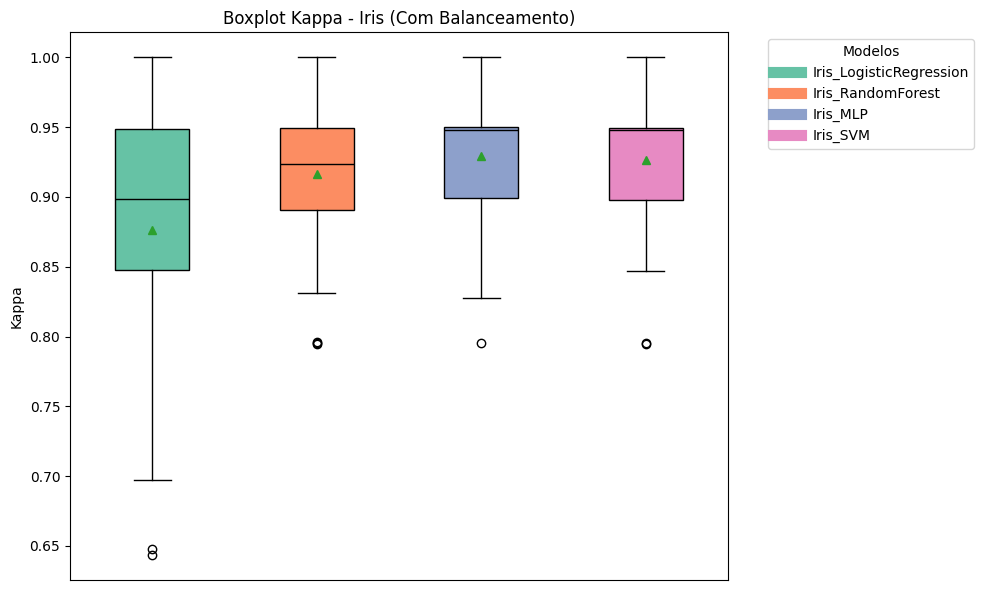

In [ ]:
def plot_metric_boxplot(results_dict, metric, title, filename):
    plt.figure(figsize=(10,6))
    data = []
    labels = []
    for key, df in results_dict.items():
        if metric in df.columns:
            data.append(df[metric])
            labels.append(key)
    # Definindo uma cor diferente para cada modelo
    colors = plt.cm.Set2.colors  # Paleta de cores
    box_colors = [colors[i % len(colors)] for i in range(len(labels))]
    bp = plt.boxplot(data, patch_artist=True, showmeans=True)
    for patch, color in zip(bp['boxes'], box_colors):
        patch.set_facecolor(color)
    for median, color in zip(bp['medians'], box_colors):
        median.set_color('black')
    for mean, color in zip(bp['means'], box_colors):
        mean.set_color('red')
    plt.ylabel(metric)
    plt.title(title)
    plt.xticks([])  # Remove os valores do eixo x
    # Adiciona legenda com os nomes dos modelos e suas cores
    handles = [plt.Line2D([0], [0], color=box_colors[i], lw=8) for i in range(len(labels))]
    plt.legend(handles, labels, title="Modelos", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f'graficos/boxplot_{filename}.png', bbox_inches='tight')

    # Boxplots comparativos das métricas dos modelos

# --- Regressão ---
energy_results = {k: v for k, v in regression_results.items() if "Energy" in k}
plot_metric_boxplot(energy_results, 'RMSE', 'Boxplot RMSE - Energy Efficiency', 'rmse_energy')
plot_metric_boxplot(energy_results, 'MAE', 'Boxplot MAE - Energy Efficiency', 'mae_energy')
plot_metric_boxplot(energy_results, 'R2', 'Boxplot R² - Energy Efficiency', 'r2_energy')

california_results = {k: v for k, v in regression_results.items() if "California" in k}
plot_metric_boxplot(california_results, 'RMSE', 'Boxplot RMSE - California Housing', 'rmse_california')
plot_metric_boxplot(california_results, 'MAE', 'Boxplot MAE - California Housing', 'mae_california')
plot_metric_boxplot(california_results, 'R2', 'Boxplot R² - California Housing', 'r2_california')

# --- Classificação SEM BALANCEAMENTO ---
wine_results = {k: v for k, v in classification_results.items() if "Wine" in k}
plot_metric_boxplot(wine_results, 'Acuracia', 'Boxplot Acurácia - Wine Quality (Sem Balanceamento)', 'acuracia_wine_sem_balanceamento')
plot_metric_boxplot(wine_results, 'F1-score', 'Boxplot F1-score - Wine Quality (Sem Balanceamento)', 'f1_wine_sem_balanceamento')
plot_metric_boxplot(wine_results, 'Kappa', 'Boxplot Kappa - Wine Quality (Sem Balanceamento)', 'kappa_wine_sem_balanceamento')

iris_results = {k: v for k, v in classification_results.items() if "Iris" in k}
plot_metric_boxplot(iris_results, 'Acuracia', 'Boxplot Acurácia - Iris (Sem Balanceamento)', 'acuracia_iris_sem_balanceamento')
plot_metric_boxplot(iris_results, 'F1-score', 'Boxplot F1-score - Iris (Sem Balanceamento)', 'f1_iris_sem_balanceamento')
plot_metric_boxplot(iris_results, 'Kappa', 'Boxplot Kappa - Iris (Sem Balanceamento)', 'kappa_iris_sem_balanceamento')

# --- Classificação COM BALANCEAMENTO ---
wine_results_b = {k: v for k, v in classification_results_b.items() if "Wine" in k}
plot_metric_boxplot(wine_results_b, 'Acuracia', 'Boxplot Acurácia - Wine Quality (Com Balanceamento)', 'acuracia_wine_com_balanceamento')
plot_metric_boxplot(wine_results_b, 'F1-score', 'Boxplot F1-score - Wine Quality (Com Balanceamento)', 'f1_wine_com_balanceamento')
plot_metric_boxplot(wine_results_b, 'Kappa', 'Boxplot Kappa - Wine Quality (Com Balanceamento)', 'kappa_wine_com_balanceamento')

iris_results_b = {k: v for k, v in classification_results_b.items() if "Iris" in k}
plot_metric_boxplot(iris_results_b, 'Acuracia', 'Boxplot Acurácia - Iris (Com Balanceamento)', 'acuracia_iris_com_balanceamento')
plot_metric_boxplot(iris_results_b, 'F1-score', 'Boxplot F1-score - Iris (Com Balanceamento)', 'f1_iris_com_balanceamento')
plot_metric_boxplot(iris_results_b, 'Kappa', 'Boxplot Kappa - Iris (Com Balanceamento)', 'kappa_iris_com_balanceamento')

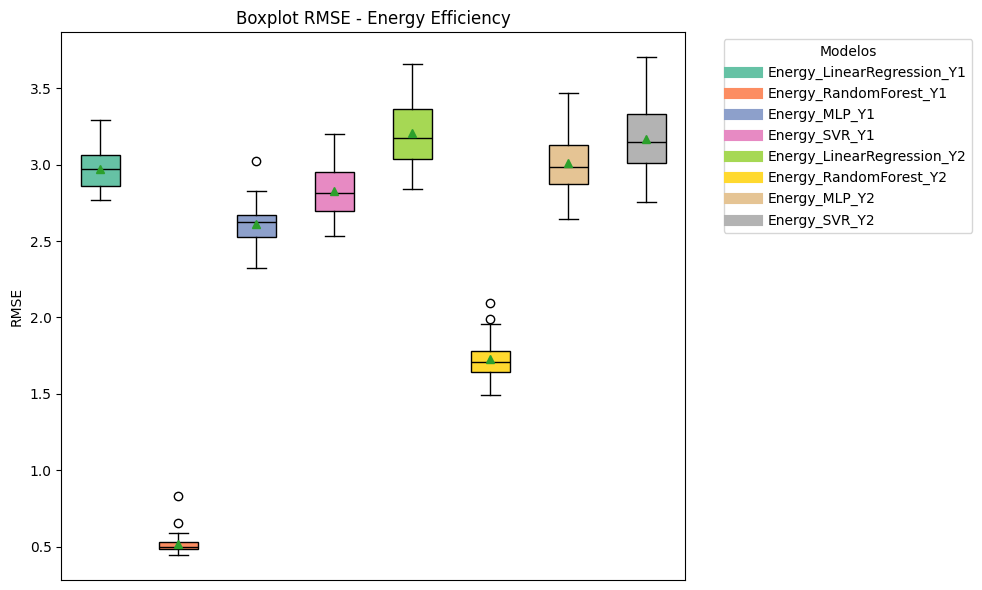

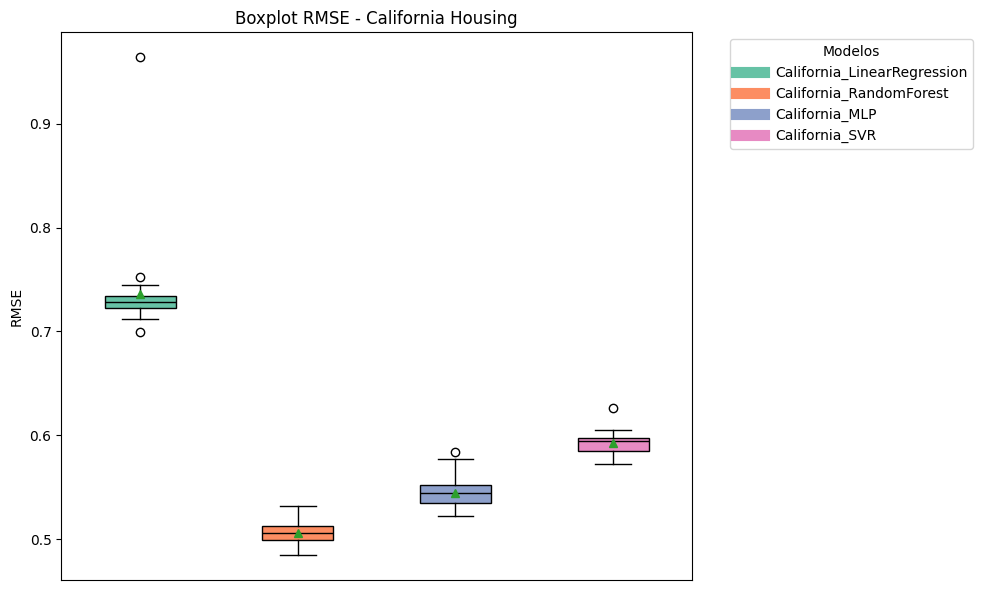

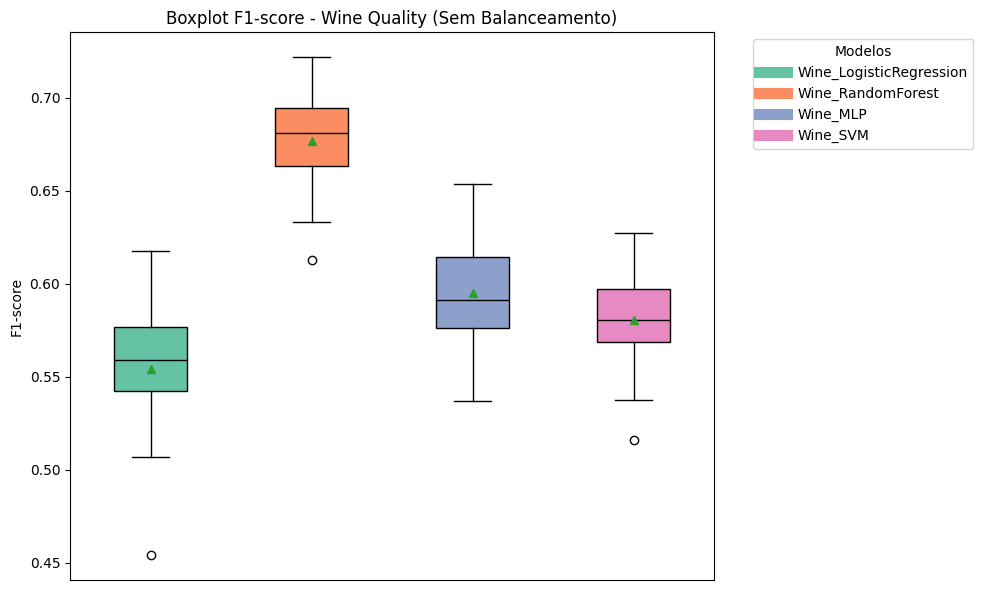

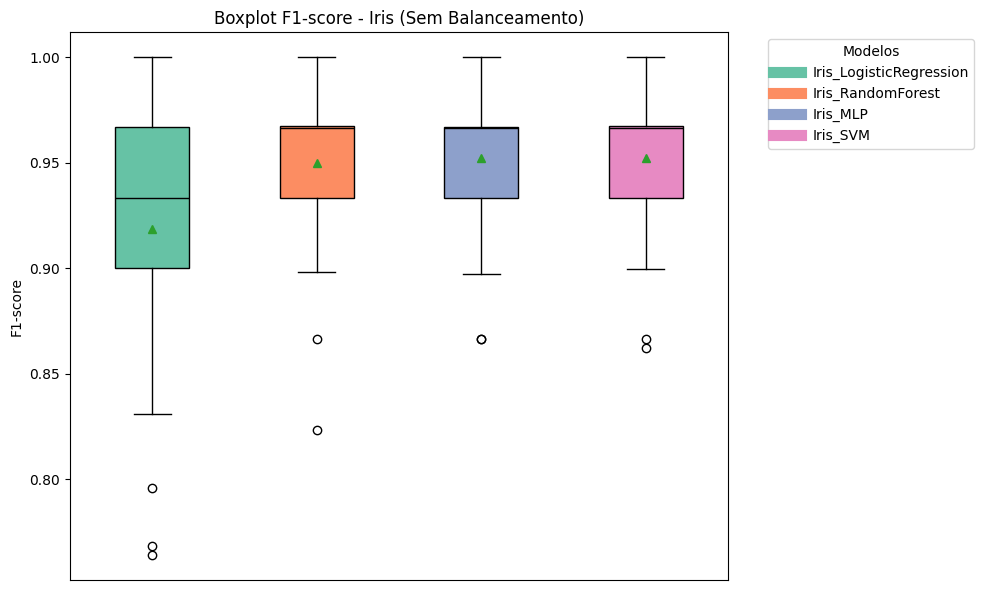

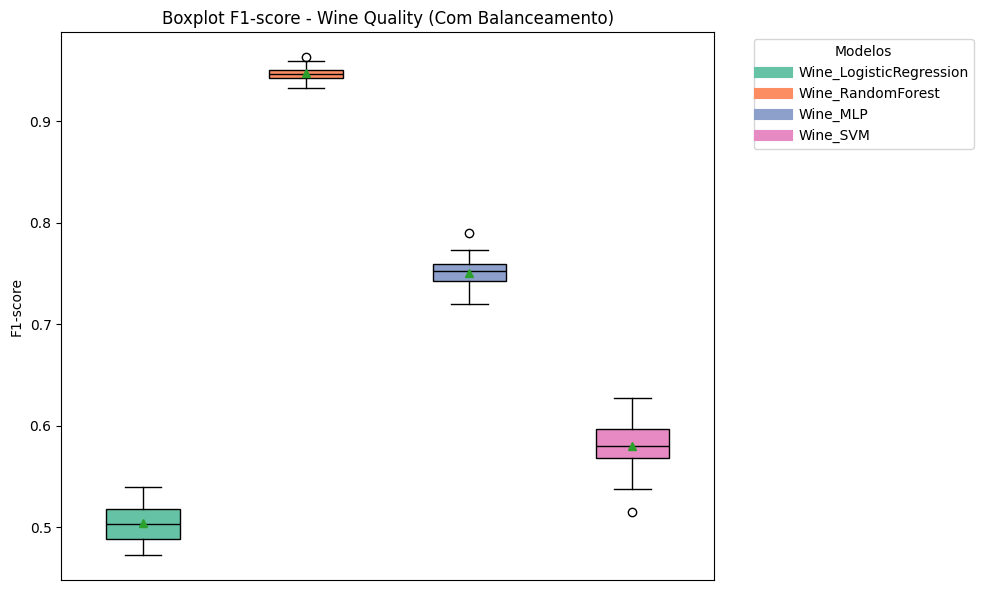

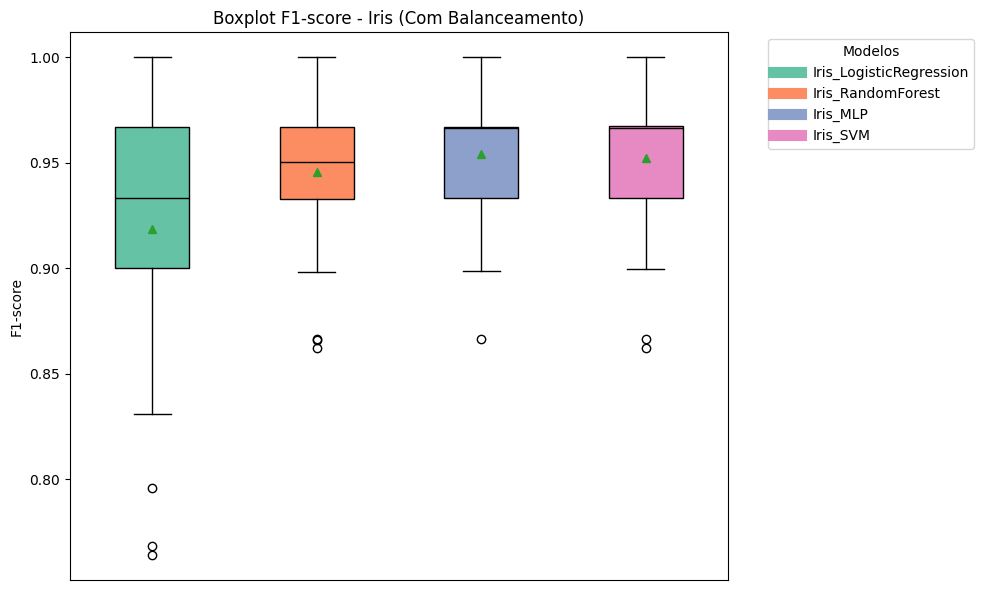

In [ ]:
# ...existing code...

# --- Regressão ---
energy_results = {k: v for k, v in regression_results.items() if "Energy" in k}
plot_metric_boxplot(energy_results, 'RMSE', 'Boxplot RMSE - Energy Efficiency', 'rmse_energy')

california_results = {k: v for k, v in regression_results.items() if "California" in k}
plot_metric_boxplot(california_results, 'RMSE', 'Boxplot RMSE - California Housing', 'rmse_california')

# --- Classificação SEM BALANCEAMENTO ---
wine_results = {k: v for k, v in classification_results.items() if "Wine" in k}
plot_metric_boxplot(wine_results, 'F1-score', 'Boxplot F1-score - Wine Quality (Sem Balanceamento)', 'f1_wine_sem_balanceamento')

iris_results = {k: v for k, v in classification_results.items() if "Iris" in k}
plot_metric_boxplot(iris_results, 'F1-score', 'Boxplot F1-score - Iris (Sem Balanceamento)', 'f1_iris_sem_balanceamento')

# --- Classificação COM BALANCEAMENTO ---
wine_results_b = {k: v for k, v in classification_results_b.items() if "Wine" in k}
plot_metric_boxplot(wine_results_b, 'F1-score', 'Boxplot F1-score - Wine Quality (Com Balanceamento)', 'f1_wine_com_balanceamento')

iris_results_b = {k: v for k, v in classification_results_b.items() if "Iris" in k}
plot_metric_boxplot(iris_results_b, 'F1-score', 'Boxplot F1-score - Iris (Com Balanceamento)', 'f1_iris_com_balanceamento')
# ...existing code...